In [10]:
"""
TCR-HLA Metadata Integration Pipeline
-------------------------------------
This script integrates high-throughput T-cell receptor (TCR) sequencing data 
with clinical HLA metadata. It implements a heuristic "Smart Deduplication" 
strategy to resolve conflicting clinical records for the same individual, 
prioritizing the retention of specific target alleles (e.g., HLA-A*02) 
and overall typing completeness.
"""

import os
import logging
import pandas as pd

# =============================================================================
# CONFIGURATION & LOGGING SETUP
# =============================================================================
logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - [%(levelname)s] - %(message)s'
)
logger = logging.getLogger(__name__)

# File Paths
TCR_DATA_PATH = 'huARdb_v2_5_cell_discovery_dataset.TCR.checked.csv'
SAMPLE_INFO_PATH = '2025_huARdb_sample_information_v2_7.csv'
OUTPUT_PATH = 'tcr_data_with_hla.csv'

# Target allele for prioritization during conflict resolution
TARGET_ALLELE_REGEX = r'A\*02'

# Comprehensive list of HLA loci of interest
HLA_COLUMNS = [
    'A_1', 'A_2', 'B_1', 'B_2', 'C_1', 'C_2',
    'DPB1_1', 'DPB1_2', 'DQA1_1', 'DQA1_2',
    'DQB1_1', 'DQB1_2', 'DRB1_1', 'DRB1_2'
]

# =============================================================================
# FUNCTIONS
# =============================================================================

def load_dataset(file_path: str, dataset_name: str) -> pd.DataFrame:
    """
    Loads a CSV file into a pandas DataFrame and logs standard QC metrics.

    Args:
        file_path (str): The system path to the input CSV file.
        dataset_name (str): Identifier used for logging output.

    Returns:
        pd.DataFrame: The loaded dataset.

    Raises:
        FileNotFoundError: If the specified file_path does not exist.
    """
    if not os.path.exists(file_path):
        logger.error(f"Input file not found: {file_path}")
        raise FileNotFoundError(f"Missing required file: {file_path}")
        
    logger.info(f"Loading {dataset_name} from {file_path}...")
    df = pd.read_csv(file_path)
    
    logger.info(f"{dataset_name} successfully loaded. Shape: {df.shape}")
    return df

def resolve_metadata_conflicts(sample_df: pd.DataFrame) -> pd.DataFrame:
    """
    Resolves conflicting clinical records for individuals with multiple entries.
    
    Implements a heuristic scoring system to select the optimal record:
    1. Highest priority: Records confirming the presence of the target allele.
    2. Secondary priority: Records with the highest number of genotyped HLA loci.

    Args:
        sample_df (pd.DataFrame): Raw clinical metadata containing potential duplicates.

    Returns:
        pd.DataFrame: A deduplicated metadata dataframe with exactly one record per individual.
    """
    logger.info("Applying heuristic conflict resolution for duplicate clinical records...")

    required_cols = ['Individual ID'] + HLA_COLUMNS
    
    # Ensure columns exist to prevent KeyError
    available_cols = [col for col in required_cols if col in sample_df.columns]
    working_sample = sample_df[available_cols].copy()

    # Step 1: Remove artificial "Multiplexed" cell pools (prevents data contamination)
    initial_count = len(working_sample)
    working_sample = working_sample[~working_sample['Individual ID'].astype(str).str.contains('Multiplex', case=False, na=False)]
    logger.info(f"Removed {initial_count - len(working_sample)} 'Multiplexed' artifact records.")

    # Step 2: Calculate 'Information Completeness' (Count of non-null HLA fields)
    available_hla_cols = [col for col in HLA_COLUMNS if col in working_sample.columns]
    working_sample['completeness'] = working_sample[available_hla_cols].notna().sum(axis=1)

    # Step 3: Flag rows containing the priority target allele (e.g., HLA-A*02)
    has_target_in_a1 = working_sample['A_1'].astype(str).str.contains(TARGET_ALLELE_REGEX, case=False, na=False, regex=True)
    has_target_in_a2 = working_sample['A_2'].astype(str).str.contains(TARGET_ALLELE_REGEX, case=False, na=False, regex=True)
    working_sample['has_priority_allele'] = has_target_in_a1 | has_target_in_a2

    # Step 4: Sort descending by priority allele presence, then by completeness score
    working_sample_sorted = working_sample.sort_values(
        by=['has_priority_allele', 'completeness'], 
        ascending=[False, False]
    )

    # Step 5: Deterministic deduplication (keep the optimal sorted record)
    resolved_subset = working_sample_sorted.drop_duplicates(subset=['Individual ID'], keep='first')
    
    # Clean up temporary heuristic columns
    resolved_subset = resolved_subset.drop(columns=['completeness', 'has_priority_allele'])

    logger.info(f"Conflict resolution complete. Unique individuals established: {len(resolved_subset)}")
    return resolved_subset

def integrate_tcr_and_hla(tcr_df: pd.DataFrame, resolved_sample_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merges TCR sequencing data with resolved HLA metadata.

    Args:
        tcr_df (pd.DataFrame): TCR sequencing dataset.
        resolved_sample_df (pd.DataFrame): Deduplicated clinical HLA metadata.

    Returns:
        pd.DataFrame: The integrated dataset.
    """
    logger.info("Executing Left Join to integrate HLA genotypes with TCR clones...")

    merged_df = pd.merge(
        tcr_df,
        resolved_sample_df,
        left_on='individual',
        right_on='Individual ID',
        how='left'
    )

    # Validate mapping success rate based on the A_1 locus
    missing_hla = merged_df['A_1'].isna().sum()
    total_records = len(merged_df)
    match_rate = (1 - (missing_hla / total_records)) * 100
    
    logger.info(f"Integration complete. Final dataset shape: {merged_df.shape}")
    logger.info(f"Global HLA Match Rate: {match_rate:.2f}% ({total_records - missing_hla}/{total_records} records mapped)")

    return merged_df

# =============================================================================
# MAIN EXECUTION PIPELINE
# =============================================================================

def main():
    try:
        # 1. Load raw datasets
        tcr_data = load_dataset(TCR_DATA_PATH, "TCR Sequence Dataset")
        sample_info = load_dataset(SAMPLE_INFO_PATH, "Clinical Metadata")

        # 2. Resolve clinical metadata conflicts (Smart Deduplication)
        resolved_metadata = resolve_metadata_conflicts(sample_info)

        # 3. Integrate metadata into single-cell TCR level
        integrated_data = integrate_tcr_and_hla(tcr_data, resolved_metadata)

        # 4. Export finalized dataset
        logger.info(f"Exporting integrated dataset to {OUTPUT_PATH}...")
        integrated_data.to_csv(OUTPUT_PATH, index=False)
        logger.info("Pipeline executed successfully.")

    except Exception as e:
        logger.error(f"Pipeline execution failed: {str(e)}", exc_info=True)

if __name__ == "__main__":
    main()

2026-05-11 17:45:16,425 - [INFO] - Loading TCR Sequence Dataset from huARdb_v2_5_cell_discovery_dataset.TCR.checked.csv...
2026-05-11 17:45:19,412 - [INFO] - TCR Sequence Dataset successfully loaded. Shape: (1444714, 12)
2026-05-11 17:45:19,412 - [INFO] - Loading Clinical Metadata from 2025_huARdb_sample_information_v2_7.csv...
2026-05-11 17:45:19,425 - [INFO] - Clinical Metadata successfully loaded. Shape: (1793, 35)
2026-05-11 17:45:19,425 - [INFO] - Applying heuristic conflict resolution for duplicate clinical records...
2026-05-11 17:45:19,428 - [INFO] - Removed 377 'Multiplexed' artifact records.
2026-05-11 17:45:19,441 - [INFO] - Conflict resolution complete. Unique individuals established: 823
2026-05-11 17:45:19,442 - [INFO] - Executing Left Join to integrate HLA genotypes with TCR clones...
2026-05-11 17:45:19,955 - [INFO] - Integration complete. Final dataset shape: (1444714, 27)
2026-05-11 17:45:19,956 - [INFO] - Global HLA Match Rate: 94.28% (1362117/1444714 records mapped)

2026-05-11 17:45:33,410 - [INFO] - Loading data from tcr_data_with_hla.csv...
2026-05-11 17:45:39,337 - [INFO] - Executing cohort classification...
2026-05-11 17:45:42,431 - [INFO] - Classification complete: HLA-A*02(+) n=291, HLA-A*02(-) n=248
2026-05-11 17:45:42,501 - [INFO] - Generating donut plot...
2026-05-11 17:45:42,657 - [INFO] - maxp pruned
2026-05-11 17:45:42,657 - [INFO] - LTSH dropped
2026-05-11 17:45:42,658 - [INFO] - cmap pruned
2026-05-11 17:45:42,659 - [INFO] - kern dropped
2026-05-11 17:45:42,663 - [INFO] - post pruned
2026-05-11 17:45:42,664 - [INFO] - PCLT dropped
2026-05-11 17:45:42,665 - [INFO] - JSTF dropped
2026-05-11 17:45:42,667 - [INFO] - DSIG dropped
2026-05-11 17:45:42,671 - [INFO] - GPOS pruned
2026-05-11 17:45:42,674 - [INFO] - GSUB pruned
2026-05-11 17:45:42,681 - [INFO] - glyf pruned
2026-05-11 17:45:42,684 - [INFO] - Added gid0 to subset
2026-05-11 17:45:42,686 - [INFO] - Added first four glyphs to subset
2026-05-11 17:45:42,687 - [INFO] - Closing glyph

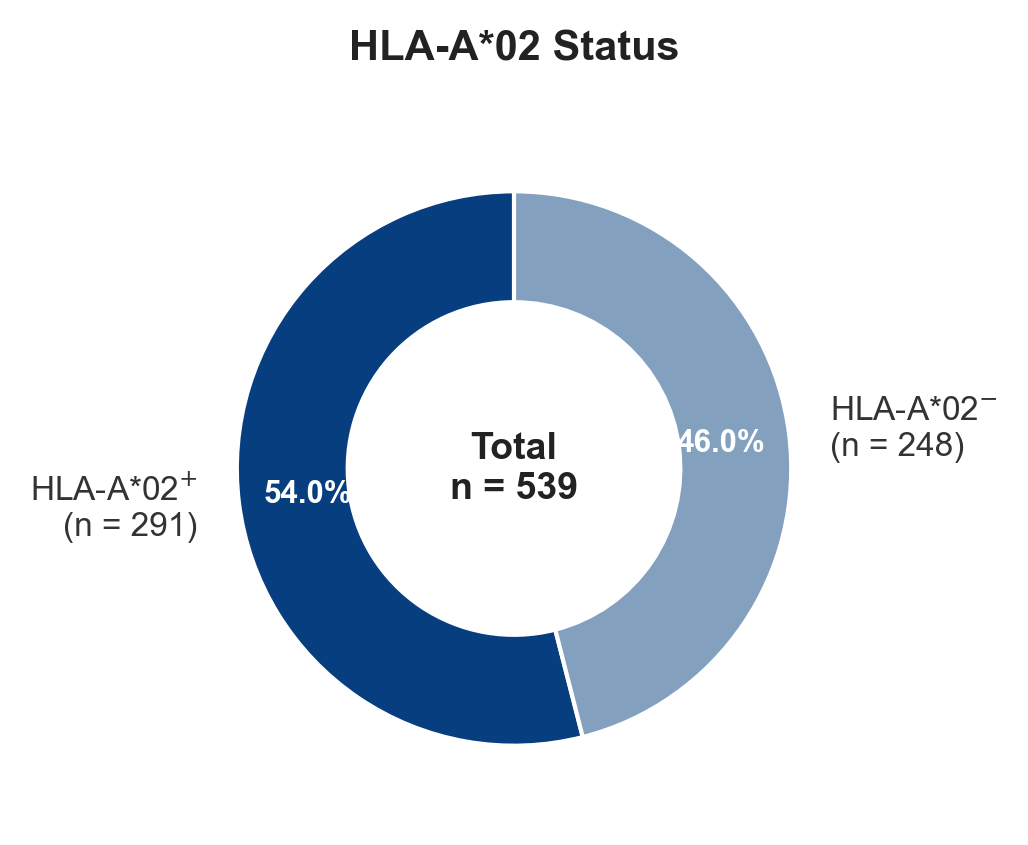

In [11]:
"""
HLA-A*02 Cohort Distribution Analysis
-------------------------------------
Parses integrated TCR-HLA single-cell metadata to classify individuals 
into HLA-A*02 positive and negative cohorts. Generates a publication-ready 
donut chart characterizing the final dataset composition.
"""

import os
import logging
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =============================================================================
# CONFIGURATION & LOGGING
# =============================================================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s] - %(message)s')
logger = logging.getLogger(__name__)

# File Paths
INPUT_PATH = 'tcr_data_with_hla.csv'
OUTPUT_PDF = 'fig5a_HLA_A02_donut.pdf'

def set_publication_style():
    """
    Configures Matplotlib parameters to meet Nature/Cell publication standards.
    Ensures text is embedded as TrueType fonts (editable in Adobe Illustrator).
    """
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'axes.linewidth': 0.8,
        'axes.titlesize': 10,
        'figure.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.transparent': True
    })

def classify_cohort(df: pd.DataFrame) -> tuple:
    """
    Classifies unique individuals into A*02+ and A*02- cohorts using robust 
    set theory to handle conflicting clinical records.
    """
    logger.info("Executing cohort classification...")

    # Identify the primary key column
    id_col = 'Individual ID' if 'Individual ID' in df.columns else 'individual'
    if id_col not in df.columns:
        raise ValueError("Individual ID column not found in dataset.")

    # 1. Filter out artificial cell pools (e.g., 10x Multiplexed lanes)
    initial_len = len(df)
    df = df[~df[id_col].astype(str).str.contains('Multiplex', case=False, na=False)]
    if initial_len > len(df):
        logger.info(f"Filtered {initial_len - len(df)} artifact records (e.g., 'Multiplex').")

    # 2. Identify Positive Cohort (High-tolerance regex matching)
    a1_pos = df['A_1'].astype(str).str.contains(r'A\*02', case=False, na=False, regex=True)
    a2_pos = df['A_2'].astype(str).str.contains(r'A\*02', case=False, na=False, regex=True)
    hla02pos_individuals = set(df[a1_pos | a2_pos][id_col].dropna().unique())

    # 3. Identify Fully Typed Cohort (Strict null-value checking)
    a1_valid = df['A_1'].notna() & (df['A_1'].astype(str).str.strip().str.upper() != 'NAN')
    a2_valid = df['A_2'].notna() & (df['A_2'].astype(str).str.strip().str.upper() != 'NAN')
    both_typed_individuals = set(df[a1_valid & a2_valid][id_col].dropna().unique())

    # 4. Resolve Negative Cohort (Mutually exclusive set subtraction)
    # If a patient has conflicting records, their positive status supersedes.
    hla02neg_individuals = both_typed_individuals - hla02pos_individuals

    # 5. Intersect with patients actually possessing TCR data
    tcr_individuals = set(df[id_col].dropna().unique())
    n_pos = len(hla02pos_individuals & tcr_individuals)
    n_neg = len(hla02neg_individuals & tcr_individuals)

    logger.info(f"Classification complete: HLA-A*02(+) n={n_pos}, HLA-A*02(-) n={n_neg}")
    return n_pos, n_neg

def plot_donut_chart(n_pos: int, n_neg: int, output_path: str):
    """
    Renders and exports a high-contrast, editable donut chart.
    """
    logger.info("Generating donut plot...")
    
    sizes = [n_pos, n_neg]
    labels = [f'HLA-A*02$^{{+}}$\n(n = {n_pos})', f'HLA-A*02$^{{-}}$\n(n = {n_neg})']
    colors = ['#073e7f', '#83a0be']  # Dark blue, Light blue

    # Standard single-panel figure size (3.0 x 3.0 inches)
    fig, ax = plt.subplots(figsize=(3.0, 3.0))
    
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels, 
        colors=colors,
        autopct='%1.1f%%', 
        startangle=90,
        pctdistance=0.75, 
        labeldistance=1.15,
        wedgeprops=dict(width=0.4, linewidth=1.0, edgecolor='white'),
        textprops=dict(fontsize=8, color='#333333')
    )
    
    # Style internal percentage text for readability
    for t in autotexts:
        t.set_fontsize(7.5)
        t.set_fontweight('bold')
        t.set_color('white')

    # Central total N annotation
    ax.text(0, 0, f'Total\nn = {n_pos + n_neg}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='#222222')
    
    ax.set_title('HLA-A*02 Status', fontsize=10, fontweight='bold', pad=15, color='#222222')
    
    plt.savefig(output_path)
    logger.info(f"Figure successfully saved to: {output_path}")
    plt.show()

def main():
    try:
        if not os.path.exists(INPUT_PATH):
            raise FileNotFoundError(f"Missing required dataset: {INPUT_PATH}")

        set_publication_style()
        
        logger.info(f"Loading data from {INPUT_PATH}...")
        df = pd.read_csv(INPUT_PATH)

        n_pos, n_neg = classify_cohort(df)
        plot_donut_chart(n_pos, n_neg, OUTPUT_PDF)

    except Exception as e:
        logger.error(f"Execution failed: {str(e)}", exc_info=True)

if __name__ == "__main__":
    main()

2026-05-11 17:46:36,836 - [INFO] - Loading data from tcr_data_with_hla.csv
2026-05-11 17:46:43,082 - [INFO] - Filtered 0 artifact records (e.g., 'Multiplex').
2026-05-11 17:46:45,886 - [INFO] - Processed counts for All Data cohort.
2026-05-11 17:46:46,596 - [INFO] - Processed counts for A*02$^{+}$ cohort.
2026-05-11 17:46:47,278 - [INFO] - Processed counts for A*02$^{-}$ cohort.
2026-05-11 17:46:47,279 - [INFO] - Rendering publication-quality stacked bar plot...
2026-05-11 17:46:47,484 - [INFO] - maxp pruned
2026-05-11 17:46:47,485 - [INFO] - LTSH dropped
2026-05-11 17:46:47,485 - [INFO] - cmap pruned
2026-05-11 17:46:47,486 - [INFO] - kern dropped
2026-05-11 17:46:47,491 - [INFO] - post pruned
2026-05-11 17:46:47,492 - [INFO] - PCLT dropped
2026-05-11 17:46:47,492 - [INFO] - JSTF dropped
2026-05-11 17:46:47,493 - [INFO] - DSIG dropped
2026-05-11 17:46:47,498 - [INFO] - GPOS pruned
2026-05-11 17:46:47,501 - [INFO] - GSUB pruned
2026-05-11 17:46:47,507 - [INFO] - glyf pruned
2026-05-11 

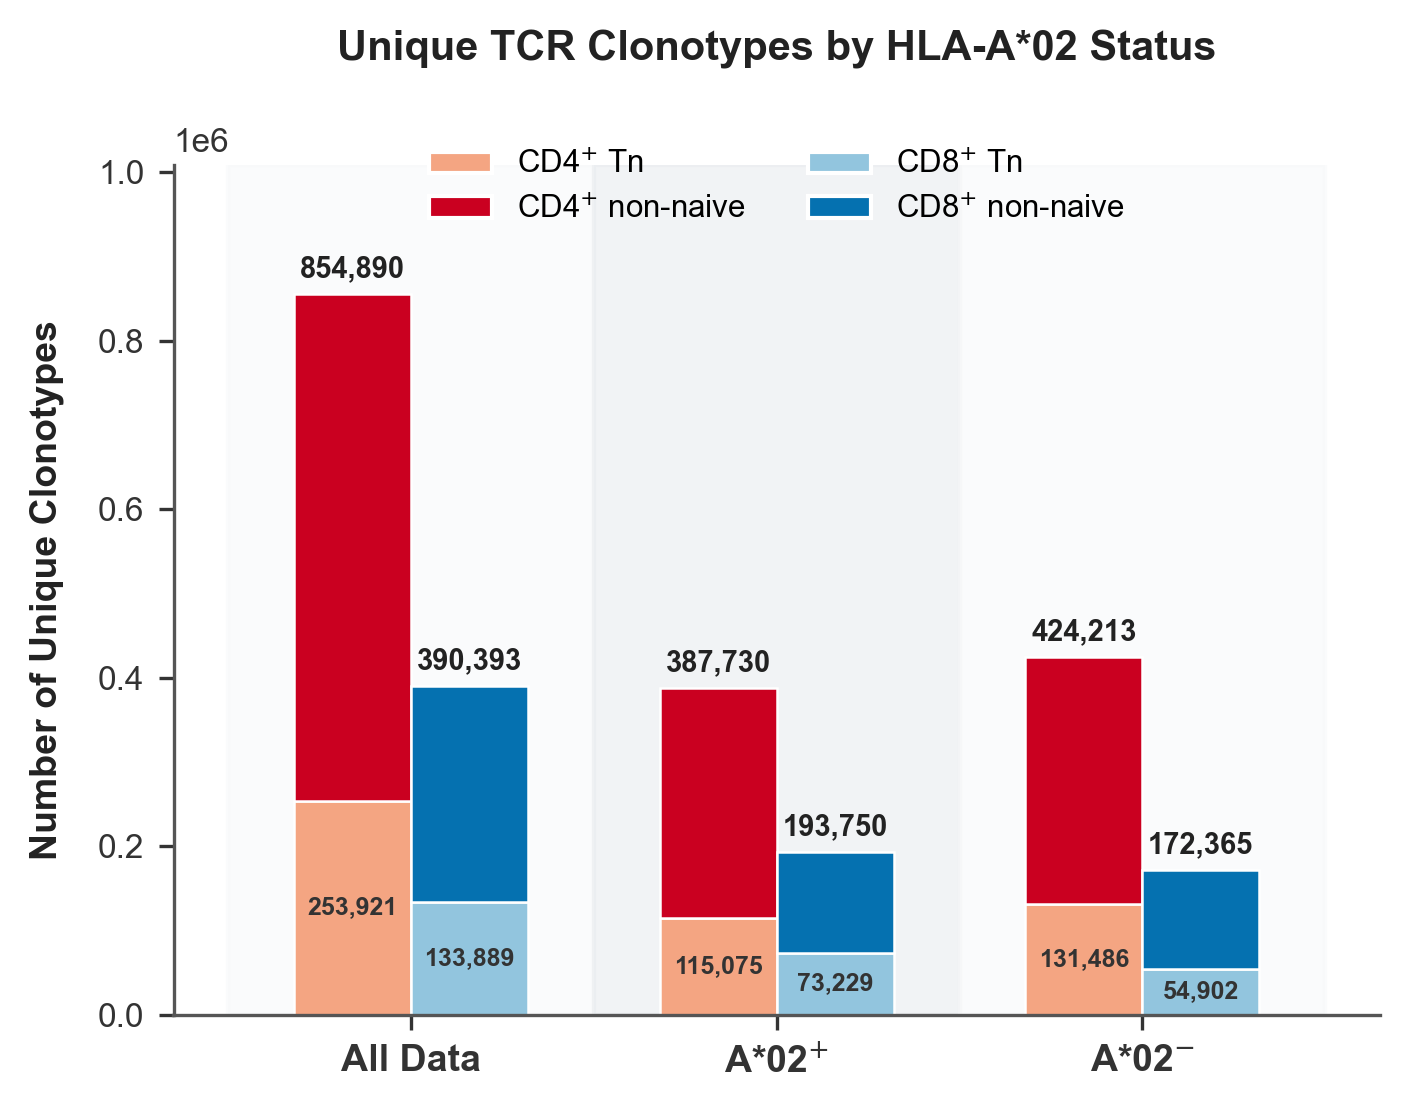

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.patches import Patch
import logging

# =============================================================================
# CONFIGURATION & LOGGING SETUP
# =============================================================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s] - %(message)s')
logger = logging.getLogger(__name__)

# Nature-style typographic and aesthetic configuration
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'pdf.fonttype': 42,   # Ensures text is editable in Illustrator
    'ps.fonttype': 42,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'figure.dpi': 300,
    'savefig.transparent': True
})

TCR_PATH = 'tcr_data_with_hla.csv'
OUTPUT_PDF = 'fig5a_HLA_A02_merged_stacked_barplot.pdf'

# =============================================================================
# High-Contrast Publication Palette
# =============================================================================
# Corrected mapping: Naive = Light/Soft tones, Non-naive = Deep/Bold tones
CD4_NAIVE_COLOR = '#F4A582'         # Soft Salmon/Peach
CD4_NON_NAIVE_COLOR = '#CA0020'     # Deep Crimson/Brick Red

CD8_NAIVE_COLOR = '#92C5DE'         # Soft Sky Blue
CD8_NON_NAIVE_COLOR = '#0571B0'     # Deep Navy/Cobalt

# Alternating background panel colors for grouped bars
BG_COLORS = ['#F8F9FA', '#E9ECEF', '#F8F9FA']

def load_and_process_data(filepath: str) -> dict:
    """
    Loads dataset, applies strict artifact filtering, and segments 
    individuals into All, HLA-A*02+, and HLA-A*02- cohorts.
    """
    logger.info(f"Loading data from {filepath}")
    tcr_data = pd.read_csv(filepath)

    # 1. Filter out artificial cell pools (e.g., 10x Multiplexed lanes)
    initial_len = len(tcr_data)
    tcr_data = tcr_data[~tcr_data['individual'].astype(str).str.contains('Multiplex', case=False, na=False)]
    logger.info(f"Filtered {initial_len - len(tcr_data)} artifact records (e.g., 'Multiplex').")

    # Standardize HLA strings safely
    tcr_data['A_1_str'] = tcr_data['A_1'].astype(str).str.strip().str.upper()
    tcr_data['A_2_str'] = tcr_data['A_2'].astype(str).str.strip().str.upper()

    id_col = 'Individual ID' if 'Individual ID' in tcr_data.columns else 'individual'
    sample_info = tcr_data[[id_col, 'A_1_str', 'A_2_str']].drop_duplicates()

    # 2. Robust positive identification (Regex logic)
    a1_pos = sample_info['A_1_str'].str.contains(r'A\*02', case=False, na=False, regex=True)
    a2_pos = sample_info['A_2_str'].str.contains(r'A\*02', case=False, na=False, regex=True)
    hla02pos_individuals = set(sample_info[a1_pos | a2_pos][id_col])

    # 3. Robust negative identification (Strict typing validation)
    both_typed_mask = (sample_info['A_1_str'] != 'NAN') & (sample_info['A_2_str'] != 'NAN')
    # Mutually exclusive: If conflict, positive status takes absolute priority
    hla02neg_individuals = set(sample_info[both_typed_mask][id_col].unique()) - hla02pos_individuals

    # 4. Final cross-reference with TCR data
    tcr_individuals = set(tcr_data[id_col].dropna().unique())
    a02pos_in_tcr = hla02pos_individuals & tcr_individuals
    a02neg_in_tcr = hla02neg_individuals & tcr_individuals

    # 5. Create final dictionary groups
    groups = {
        'All Data': tcr_data,
        'A*02$^{+}$': tcr_data[tcr_data[id_col].isin(a02pos_in_tcr)],
        'A*02$^{-}$': tcr_data[tcr_data[id_col].isin(a02neg_in_tcr)]
    }
    return groups

def calculate_clonotype_counts(groups: dict) -> dict:
    """Calculates naive and non-naive unique clonotype counts for CD4 and CD8."""
    counts = {}
    for label, data in groups.items():
        counts[label] = {}
        for lineage in ['CD4', 'CD8']:
            # Exact sequence unique counting
            total = data[data['cell_subtype_v3_major'] == lineage]['tcr'].nunique()
            naive = data[data['cell_subtype_v3'] == f'{lineage}+ Tn']['tcr'].nunique()
            non_naive = total - naive

            counts[label][f'{lineage}_naive'] = naive
            counts[label][f'{lineage}_non_naive'] = non_naive
            counts[label][f'{lineage}_total'] = total

        logger.info(f"Processed counts for {label} cohort.")
    return counts

def plot_stacked_bars(counts: dict, output_path: str):
    """Renders and exports the high-contrast stacked bar plot."""
    logger.info("Rendering publication-quality stacked bar plot...")
    
    group_labels = list(counts.keys())
    x = np.arange(len(group_labels))
    width = 0.32  # Slimmer bars for elegance

    cd4_naive = [counts[g]['CD4_naive'] for g in group_labels]
    cd4_non_naive = [counts[g]['CD4_non_naive'] for g in group_labels]
    cd8_naive = [counts[g]['CD8_naive'] for g in group_labels]
    cd8_non_naive = [counts[g]['CD8_non_naive'] for g in group_labels]

    # Nature-style compact figure size
    fig, ax = plt.subplots(figsize=(4.8, 3.8), dpi=300)

    # Background shading for grouped visual parsing
    for i, bg in enumerate(BG_COLORS):
        ax.axvspan(i - 0.5, i + 0.5, color=bg, zorder=0, alpha=0.6)

    # CD4 Stack (Naive on bottom, Non-naive on top)
    ax.bar(x - width/2, cd4_naive, width, 
           color=CD4_NAIVE_COLOR, edgecolor='white', linewidth=0.6, zorder=2)
    ax.bar(x - width/2, cd4_non_naive, width, bottom=cd4_naive, 
           color=CD4_NON_NAIVE_COLOR, edgecolor='white', linewidth=0.6, zorder=2)

    # CD8 Stack
    ax.bar(x + width/2, cd8_naive, width, 
           color=CD8_NAIVE_COLOR, edgecolor='white', linewidth=0.6, zorder=2)
    ax.bar(x + width/2, cd8_non_naive, width, bottom=cd8_naive, 
           color=CD8_NON_NAIVE_COLOR, edgecolor='white', linewidth=0.6, zorder=2)

    # Label adjustments & Y-axis buffer
    ymax = max([counts[g]['CD4_total'] for g in group_labels] + 
               [counts[g]['CD8_total'] for g in group_labels])
    ax.set_ylim(0, ymax * 1.18) # 18% headspace for labels and legend

    # Value Labels
    for i, g in enumerate(group_labels):
        # Top totals
        ax.text(x[i] - width/2, counts[g]['CD4_total'] + ymax*0.015, 
                f"{counts[g]['CD4_total']:,}", ha='center', va='bottom', 
                fontsize=7, fontweight='bold', color='#222222')
        ax.text(x[i] + width/2, counts[g]['CD8_total'] + ymax*0.015, 
                f"{counts[g]['CD8_total']:,}", ha='center', va='bottom', 
                fontsize=7, fontweight='bold', color='#222222')

        # Naive inner segment labels (Use dark grey since naive colors are light)
        if cd4_naive[i] > ymax * 0.06:
            ax.text(x[i] - width/2, cd4_naive[i]/2, f"{cd4_naive[i]:,}", 
                    ha='center', va='center', fontsize=6, fontweight='bold', color='#333333')
        if cd8_naive[i] > ymax * 0.06:
            ax.text(x[i] + width/2, cd8_naive[i]/2, f"{cd8_naive[i]:,}", 
                    ha='center', va='center', fontsize=6, fontweight='bold', color='#333333')

    # Axes styling
    ax.set_ylabel('Number of Unique Clonotypes', fontweight='bold', color='#222222', labelpad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(group_labels, color='#222222', fontweight='bold', fontsize=9)
    
    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['bottom'].set_color('#555555')
    ax.tick_params(axis='both', colors='#333333')

    # Legend Construction
    legend_elements = [
        Patch(facecolor=CD4_NAIVE_COLOR, edgecolor='white', label='CD4$^{+}$ Tn'),
        Patch(facecolor=CD4_NON_NAIVE_COLOR, edgecolor='white', label='CD4$^{+}$ non-naive'),
        Patch(facecolor=CD8_NAIVE_COLOR, edgecolor='white', label='CD8$^{+}$ Tn'),
        Patch(facecolor=CD8_NON_NAIVE_COLOR, edgecolor='white', label='CD8$^{+}$ non-naive')
    ]
    ax.legend(handles=legend_elements, frameon=False, ncol=2, 
              loc='upper center', bbox_to_anchor=(0.5, 1.05))

    # Optional: Title handling (Nature often puts this in the figure legend text, 
    # but provided here cleanly if needed for presentations)
    ax.set_title('Unique TCR Clonotypes by HLA-A*02 Status', 
                 fontsize=10, fontweight='bold', pad=25, color='#222222')

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight')
    logger.info(f"Plot successfully saved to: {output_path}")
    plt.show()

def main():
    try:
        groups = load_and_process_data(TCR_PATH)
        counts = calculate_clonotype_counts(groups)
        plot_stacked_bars(counts, OUTPUT_PDF)
    except Exception as e:
        logger.error(f"Plotting pipeline failed: {e}", exc_info=True)

if __name__ == "__main__":
    main()

2026-05-11 17:37:10,847 - [INFO] - Loading and classifying data...
2026-05-11 17:37:18,442 - [INFO] - A*02pos records: 671,002
2026-05-11 17:37:18,444 - [INFO] - A*02neg records: 773,712
2026-05-11 17:37:18,445 - [INFO] - Processing TRAV...
2026-05-11 17:37:42,929 - [INFO] - Processing TRAJ...
2026-05-11 17:38:14,735 - [INFO] - Processing TRBV...
2026-05-11 17:38:41,322 - [INFO] - Processing TRBJ...
2026-05-11 17:38:50,367 - [INFO] - Generating forest plots...
2026-05-11 17:38:51,570 - [INFO] - maxp pruned
2026-05-11 17:38:51,570 - [INFO] - LTSH dropped
2026-05-11 17:38:51,571 - [INFO] - cmap pruned
2026-05-11 17:38:51,572 - [INFO] - kern dropped
2026-05-11 17:38:51,576 - [INFO] - post pruned
2026-05-11 17:38:51,576 - [INFO] - PCLT dropped
2026-05-11 17:38:51,576 - [INFO] - JSTF dropped
2026-05-11 17:38:51,577 - [INFO] - DSIG dropped
2026-05-11 17:38:51,581 - [INFO] - GPOS pruned
2026-05-11 17:38:51,583 - [INFO] - GSUB pruned
2026-05-11 17:38:51,589 - [INFO] - glyf pruned
2026-05-11 17

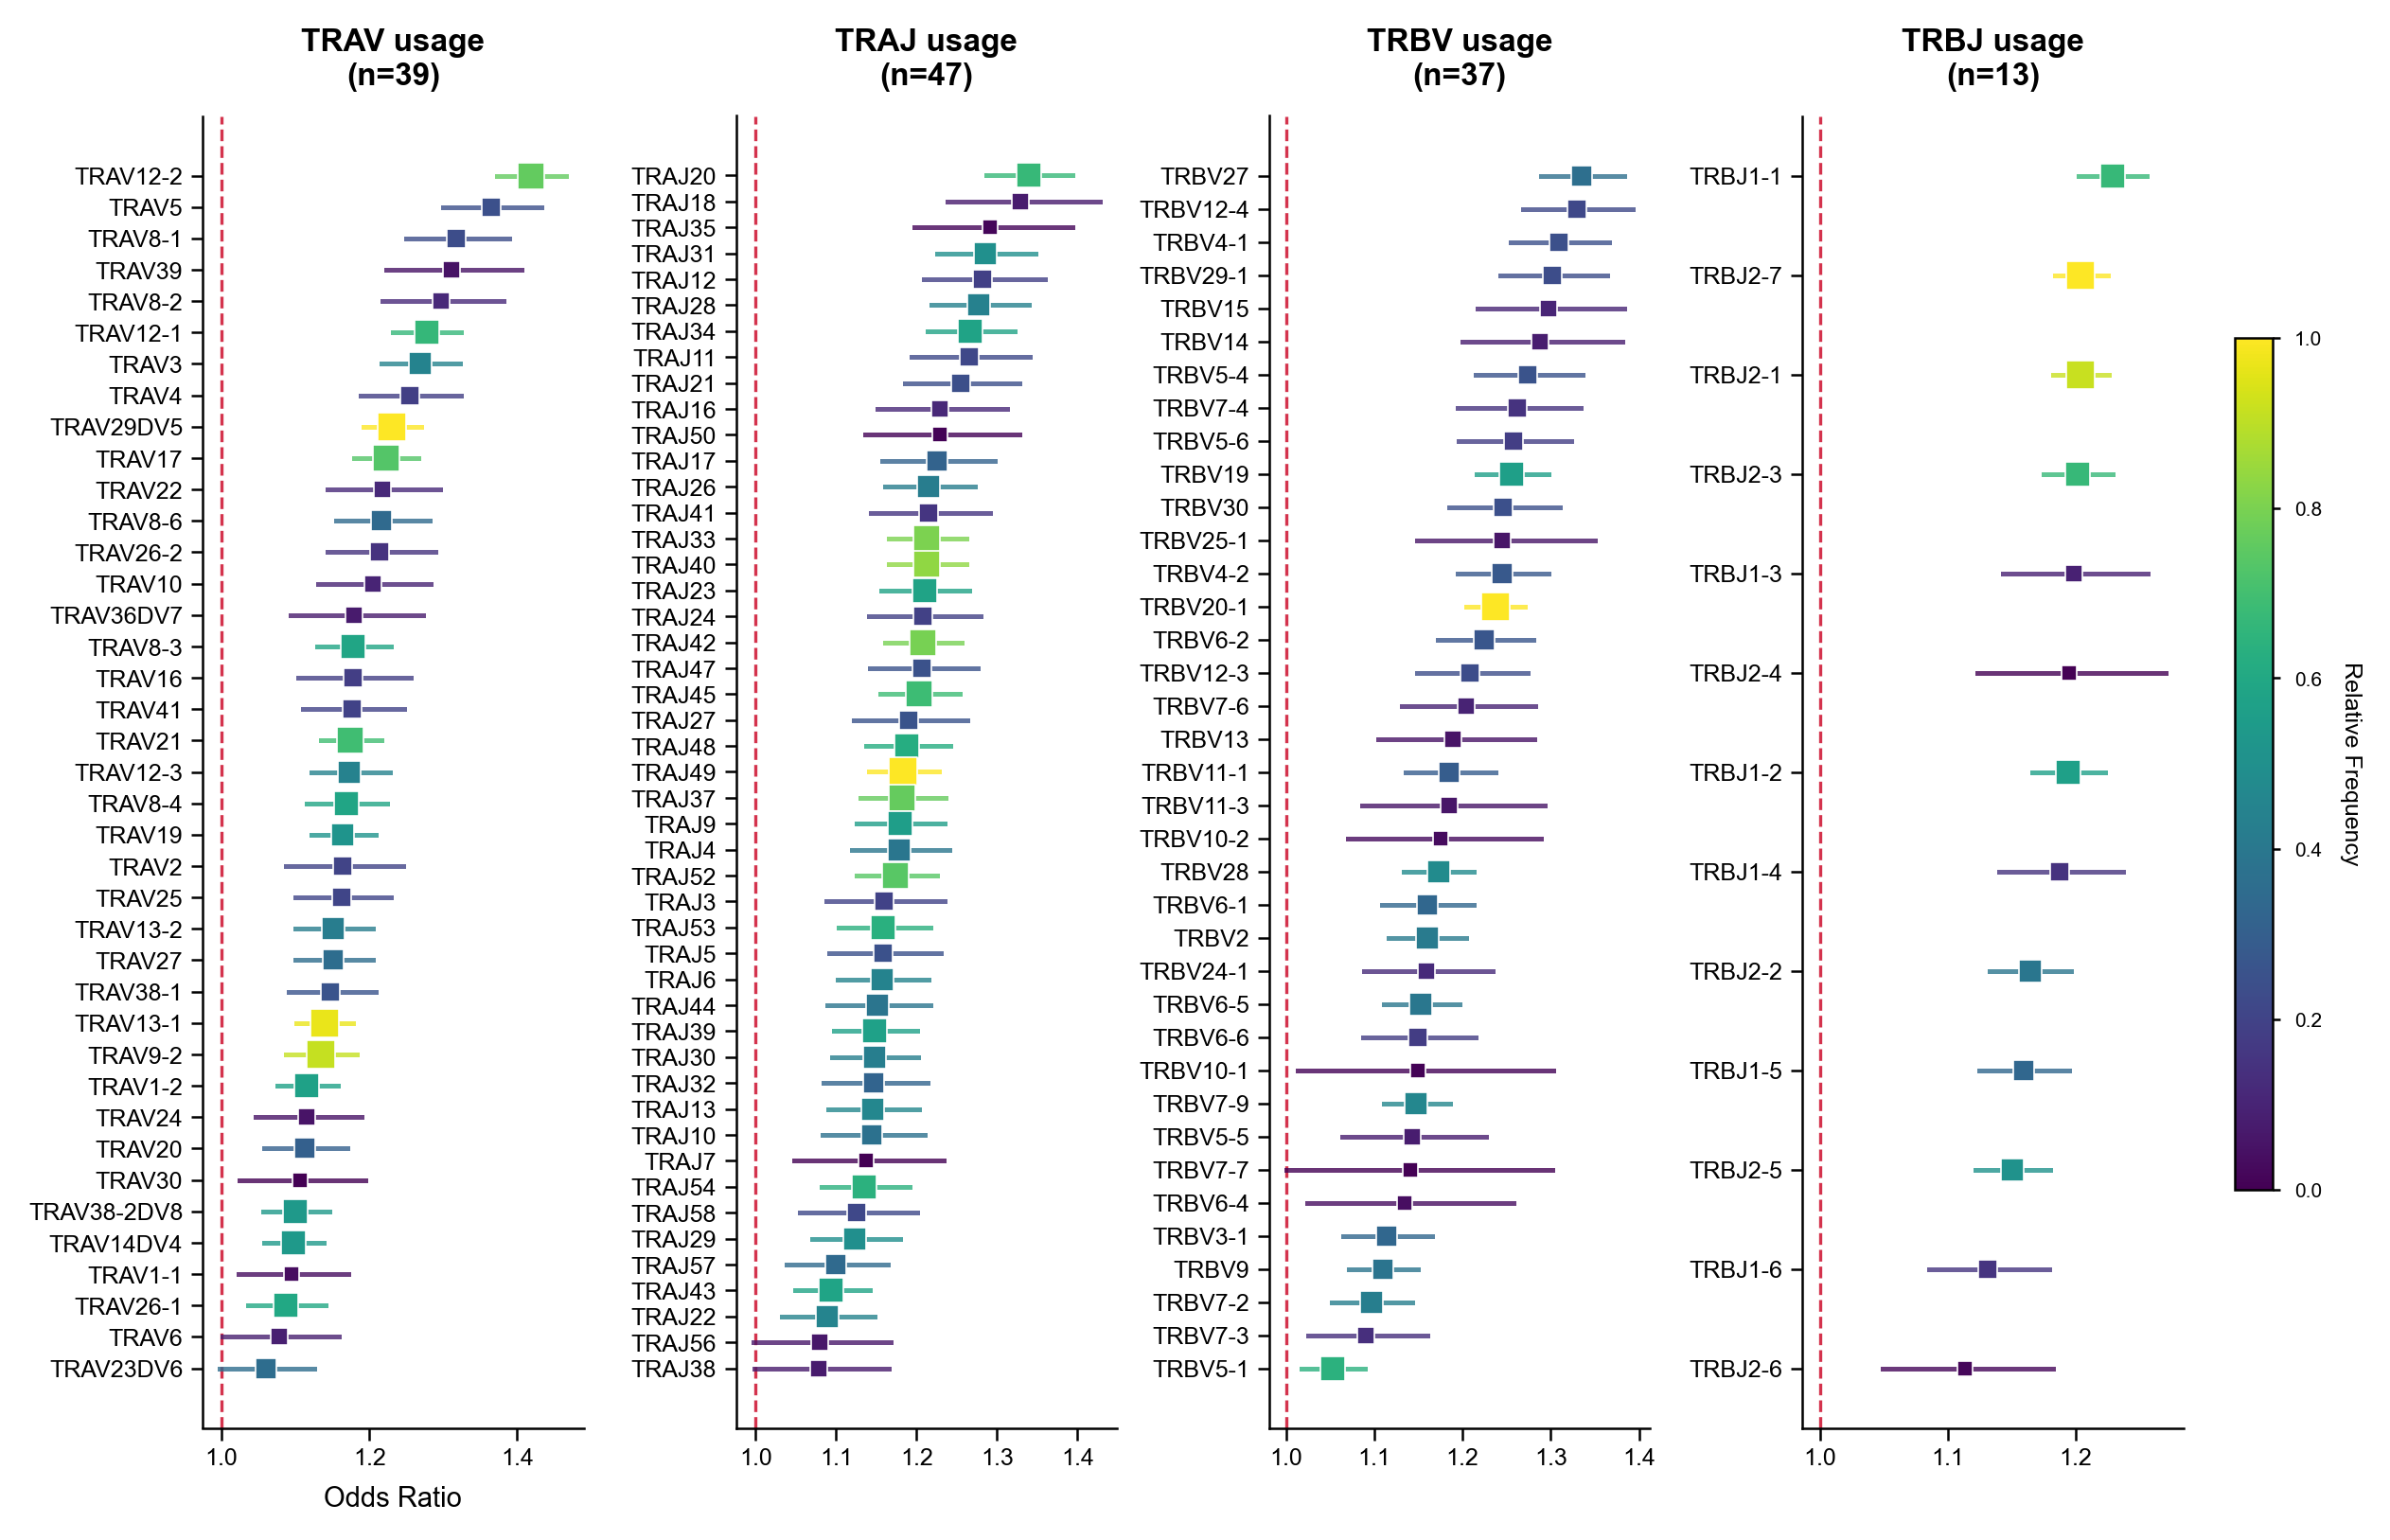

In [6]:
import pandas as pd
import numpy as np
import logging
import warnings
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Suppress specific scipy warnings if counts are extremely low
warnings.filterwarnings('ignore', category=RuntimeWarning)

# =============================================================================
# CONFIGURATION & LOGGING SETUP
# =============================================================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# File Paths
TCR_PATH = 'tcr_data_with_hla.csv'
OUTPUT_PDF = 'figS5a_A02pos_CD8_enrichment_for_all_celltypes.pdf'

def set_nature_style():
    """
    Configures Matplotlib for Nature-style publication quality.
    Standard double-column width is ~183mm (7.2 inches).
    """
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'axes.linewidth': 0.6,
        'xtick.major.width': 0.6,
        'ytick.major.width': 0.6,
        'axes.titlesize': 8,
        'axes.labelsize': 7,
        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'legend.fontsize': 6,
        'figure.dpi': 300,
    })

# =============================================================================
# DATA PROCESSING & STATS FUNCTIONS
# =============================================================================
def load_and_classify_data(filepath: str) -> pd.DataFrame:
    """Loads dataset and vectorizes HLA-A*02 classification."""
    logger.info("Loading and classifying data...")
    df = pd.read_csv(filepath)
    
    # Vectorized check for 'A*02' prefix (significantly faster than .apply)
    a1_match = df['A_1'].astype(str).str.strip().str.upper().str.startswith('A*02')
    a2_match = df['A_2'].astype(str).str.strip().str.upper().str.startswith('A*02')
    
    df['is_a02pos'] = a1_match | a2_match
    
    logger.info(f"A*02pos records: {df['is_a02pos'].sum():,}")
    logger.info(f"A*02neg records: {(~df['is_a02pos']).sum():,}")
    
    return df

def compute_enrichment(df: pd.DataFrame, gene_col: str) -> pd.DataFrame:
    """
    Calculates Fisher's Exact Test and FDR for a specific gene type.
    """
    # Cross-tabulation is much faster than manual masking in loops
    contingency_data = df.groupby([gene_col, 'is_a02pos', 'cell_subtype_v3_major']).size().unstack(fill_value=0)
    
    # Extract unique genes
    all_genes = df[gene_col].dropna().unique()
    
    results = []
    
    for gene in all_genes:
        # Construct the 2x2 table values
        try:
            a2 = df[(df[gene_col] == gene) & (df['is_a02pos'] == True) & (df['cell_subtype_v3_major'] == 'CD8')].shape[0]
            a1 = df[(df[gene_col] == gene) & (df['is_a02pos'] == True) & (df['cell_subtype_v3_major'] != 'CD8')].shape[0]
            b2 = df[(df[gene_col] == gene) & (df['is_a02pos'] == False) & (df['cell_subtype_v3_major'] == 'CD8')].shape[0]
            b1 = df[(df[gene_col] == gene) & (df['is_a02pos'] == False) & (df['cell_subtype_v3_major'] != 'CD8')].shape[0]
        except KeyError:
            continue
            
        if (a1 + a2 + b1 + b2) == 0:
            continue
            
        # A02pos-CD8 enrichment vs rest
        table = [[a2, a1], [b2, b1]]
        or_val, p_val = fisher_exact(table)
        
        # Enforce one-sided test logically
        if or_val > 1:
            _, p_val = fisher_exact(table, alternative='greater')
        else:
            _, p_val = fisher_exact(table, alternative='less')
            
        results.append({
            'gene': gene,
            'count_a02pos_cd8': a2,
            'count_a02pos_noncd8': a1,
            'count_a02neg_cd8': b2,
            'count_a02neg_noncd8': b1,
            'or_val': or_val,
            'p_val': p_val,
            'total_frequency': a1 + a2 + b1 + b2
        })
        
    res_df = pd.DataFrame(results).set_index('gene')
    res_df['prop_total'] = res_df['total_frequency'] / res_df['total_frequency'].sum()
    
    # FDR Correction
    valid_mask = res_df['p_val'].notna()
    res_df['fdr'] = np.nan
    if valid_mask.sum() > 0:
        _, p_corr, _, _ = multipletests(res_df.loc[valid_mask, 'p_val'], method='fdr_bh')
        res_df.loc[valid_mask, 'fdr'] = p_corr
        
    return res_df

# =============================================================================
# PLOTTING FUNCTION
# =============================================================================
def plot_forest_panels(freq_dfs: dict, output_path: str):
    """Renders a Nature-style 4-panel forest plot."""
    logger.info("Generating forest plots...")
    
    # 7.2 inches is the standard double-column width in Nature
    fig, axes = plt.subplots(1, 4, figsize=(9, 6), gridspec_kw={'wspace': 0.4})
    
    panel_titles = {'TRAV': 'TRAV usage', 'TRAJ': 'TRAJ usage', 
                    'TRBV': 'TRBV usage', 'TRBJ': 'TRBJ usage'}
    
    for idx, (gene_type, df_freq) in enumerate(freq_dfs.items()):
        ax = axes[idx]
        
        # Filter for significant and frequent genes
        sig = df_freq[(df_freq['fdr'] < 0.05) & (df_freq['total_frequency'] >= 4000)].copy()
        n = len(sig)
        
        if n == 0:
            ax.text(0.5, 0.5, 'No sig. genes', ha='center', va='center', fontsize=7, transform=ax.transAxes)
            ax.set_title(f'{panel_titles[gene_type]}\n(n=0)', fontsize=8, fontweight='bold')
            ax.axis('off')
            continue
            
        sig = sig.sort_values('or_val', ascending=False)
        genes = sig.index.tolist()
        odds_ratios = sig['or_val'].values
        
        # Calculate 95% CI for log Odds Ratio
        a, b, c, d = sig['count_a02pos_cd8'].values, sig['count_a02pos_noncd8'].values, \
                     sig['count_a02neg_cd8'].values, sig['count_a02neg_noncd8'].values
        
        # Add 0.5 pseudo-count to prevent division by zero
        se_log_or = np.sqrt(1/(a+0.5) + 1/(b+0.5) + 1/(c+0.5) + 1/(d+0.5))
        ci_lower = np.exp(np.log(odds_ratios) - 1.96 * se_log_or)
        ci_upper = np.exp(np.log(odds_ratios) + 1.96 * se_log_or)
        
        y_positions = np.arange(n)
        
        # Visual aesthetics based on frequency
        prop_vals = sig['prop_total'].values
        prop_norm = (prop_vals - prop_vals.min()) / (prop_vals.max() - prop_vals.min() + 1e-9)
        colors = plt.cm.viridis(prop_norm)
        sizes = 15 + prop_norm * 40  # Scaled down for smaller figure size
        
        for i in range(n):
            ax.plot([ci_lower[i], ci_upper[i]], [i, i], color=colors[i], linewidth=1.2, alpha=0.8, zorder=1)
            ax.scatter(odds_ratios[i], i, color=colors[i], s=sizes[i], marker='s',
                       edgecolors='white', linewidth=0.4, zorder=2)
            
        ax.axvline(x=1, color='#CA0020', linestyle='--', linewidth=0.8, alpha=0.8, zorder=0)
        
        ax.set_yticks(y_positions)
        ax.set_yticklabels(genes, fontsize=6)
        if idx == 0:
            ax.set_xlabel('Odds Ratio', fontsize=7)
        ax.set_title(f'{panel_titles[gene_type]}\n(n={n})', fontsize=8, fontweight='bold', pad=8)
        
        if n < 10:
            ax.set_ylim(-1, 20)  # Standardize spacing for sparse panels like TRBJ
            
        ax.invert_yaxis()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='major', length=3, pad=2)
        
    # Shared Colorbar
    sm = ScalarMappable(cmap=plt.cm.viridis, norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5]) # [left, bottom, width, height]
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Relative Frequency', fontsize=6, rotation=270, labelpad=10)
    cbar.ax.tick_params(labelsize=5, length=2)

    plt.savefig(output_path, bbox_inches='tight', transparent=True)
    logger.info(f"Figure saved to {output_path}")
    plt.show()

def main():
    set_nature_style()
    df = load_and_classify_data(TCR_PATH)
    
    gene_types = ['TRAV', 'TRAJ', 'TRBV', 'TRBJ']
    freq_dfs = {}
    
    for gt in gene_types:
        logger.info(f"Processing {gt}...")
        freq_dfs[gt] = compute_enrichment(df, gt)
        
    plot_forest_panels(freq_dfs, OUTPUT_PDF)

if __name__ == "__main__":
    main()

2026-05-04 17:31:51,974 - [INFO] - Loading dataset from tcr_data_with_hla.csv...
2026-05-04 17:31:57,979 - [INFO] - Filtered 0 artifact records.
2026-05-04 17:31:59,072 - [INFO] - Naive compartment size: 387,810
2026-05-04 17:31:59,159 - [INFO] - Computing enrichment for TRAV...
2026-05-04 17:31:59,226 - [INFO] - Computing enrichment for TRAJ...
2026-05-04 17:31:59,301 - [INFO] - Computing enrichment for TRBV...
2026-05-04 17:31:59,363 - [INFO] - Computing enrichment for TRBJ...
2026-05-04 17:31:59,410 - [INFO] - Generating publication-quality forest plots...
/var/folders/b5/nq6v9v8d4_v_xrtjdh8wnjrw0000gn/T/ipykernel_67431/884620688.py:151: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot([ci_lower[j], ci_upper[j]], [j, j], color=colors[j], linewidth=1.1, alpha=0.8)
/var/folders/b5/nq6v9v8d4_v_xr

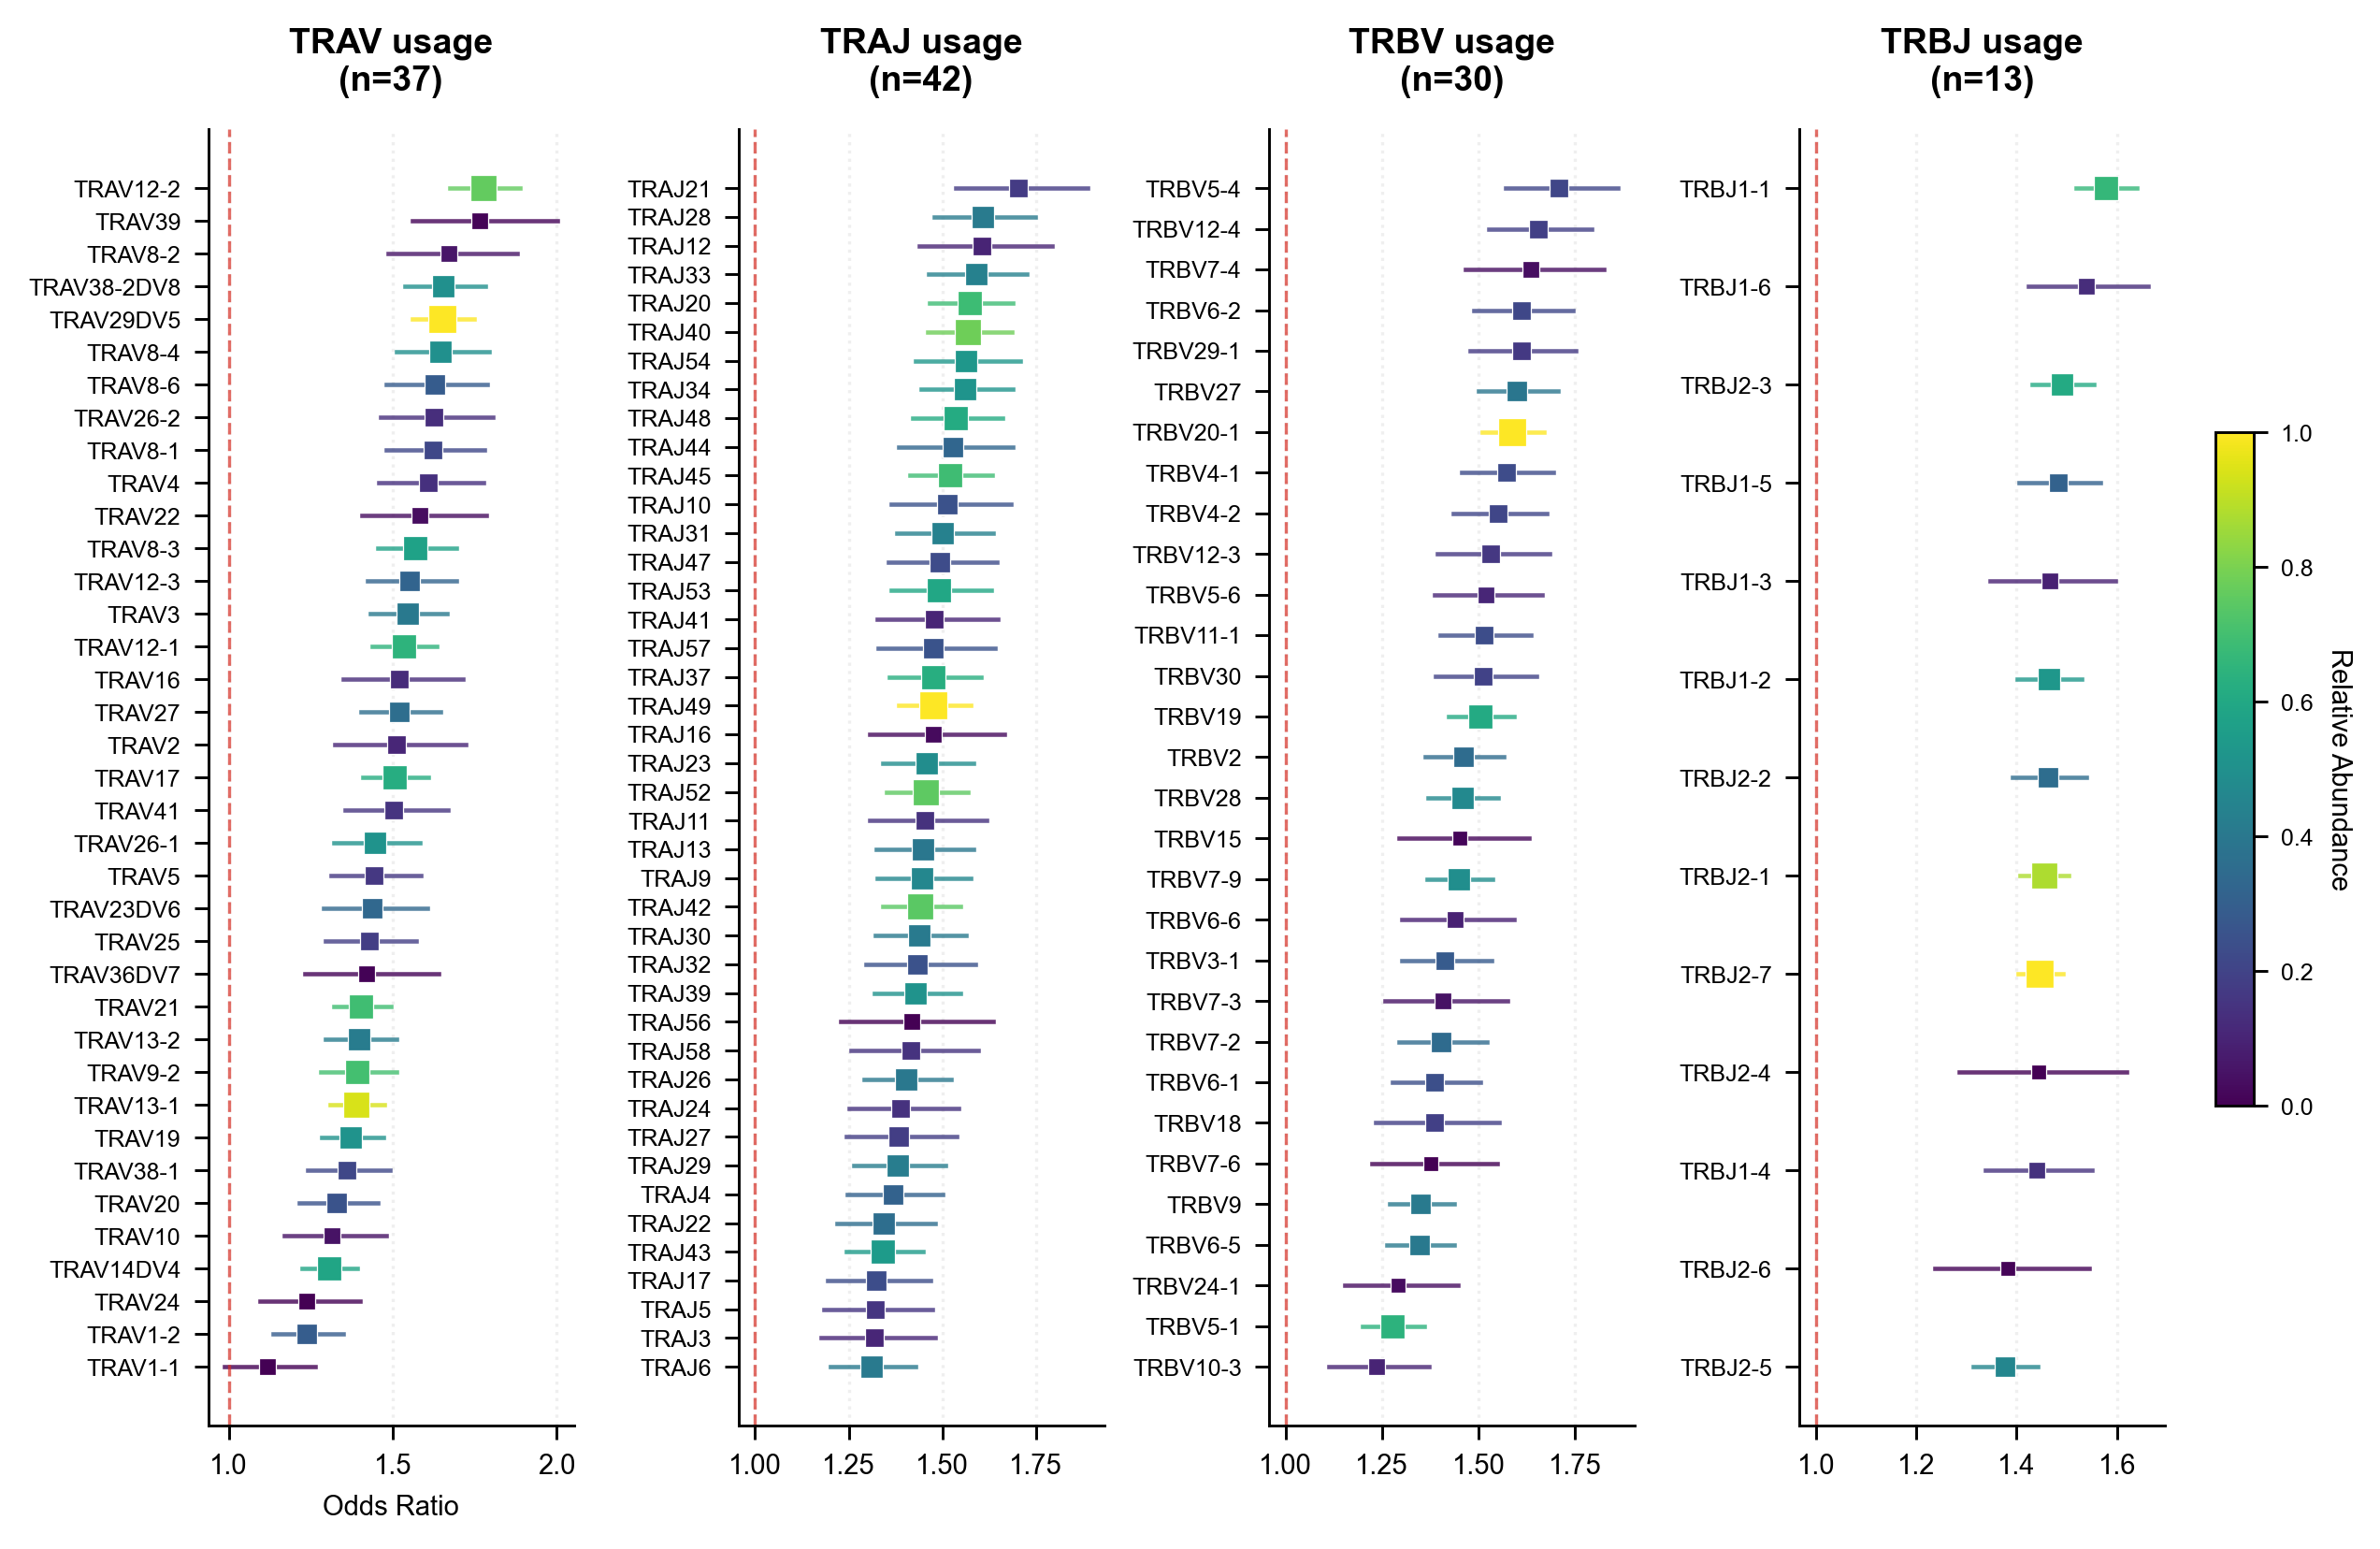

In [3]:
"""
TCR Gene Enrichment Analysis: HLA-A*02 Effect on Naive Compartment (CD8+ Tn vs CD4+ Tn)
-------------------------------------------------------------------------------------
This script assesses whether HLA-A*02 specifically shapes the TCR repertoire of 
CD8+ Naive T cells (Tn) relative to CD4+ Naive T cells. This dual-compartment 
comparison controls for population-level germline biases.
"""

import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# =============================================================================
# CONFIGURATION & LOGGING
# =============================================================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s] - %(message)s')
logger = logging.getLogger(__name__)

# Nature-style aesthetics
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.7,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'savefig.transparent': True
})

TCR_PATH = 'tcr_data_with_hla.csv'
OUTPUT_PDF = 'fig5b_HLA_A02_Naive_Selection_Enrichment.pdf'
NAIVE_COL = 'cell_subtype_v3'

# =============================================================================
# CORE PROCESSING FUNCTIONS
# =============================================================================

def load_and_preprocess(path: str) -> pd.DataFrame:
    """Loads and cleans data with artifact removal and robust HLA tagging."""
    logger.info(f"Loading dataset from {path}...")
    df = pd.read_csv(path)
    
    # 1. Artifact Removal (Deduplication and Multiplex filtering)
    initial_count = len(df)
    df = df[~df['individual'].astype(str).str.contains('Multiplex', case=False, na=False)]
    logger.info(f"Filtered {initial_count - len(df)} artifact records.")

    # 2. Robust HLA-A*02 Classification (Vectorized)
    a1_a02 = df['A_1'].astype(str).str.contains(r'A\*02', case=False, na=False, regex=True)
    a2_a02 = df['A_2'].astype(str).str.contains(r'A\*02', case=False, na=False, regex=True)
    df['is_a02pos'] = a1_a02 | a2_a02
    
    # 3. Restriction to Naive compartment
    df_naive = df[df[NAIVE_COL].isin(['CD8+ Tn', 'CD4+ Tn'])].copy()
    logger.info(f"Naive compartment size: {len(df_naive):,}")
    return df_naive

def compute_enrichment_stats(df: pd.DataFrame, gene_col: str) -> pd.DataFrame:
    """Computes Fisher's Exact Test for gene enrichment using efficient aggregation."""
    logger.info(f"Computing enrichment for {gene_col}...")
    
    # Cross-tabulate all counts in one go (much faster than nested loops)
    counts = df.groupby([gene_col, 'is_a02pos', NAIVE_COL]).size().unstack(level=[1, 2], fill_value=0)
    
    # Map column structure for clarity
    # Counts[is_a02pos][NAIVE_COL]
    results = []
    for gene in counts.index:
        try:
            a2 = counts.loc[gene, (True,  'CD8+ Tn')]  # Target: A02+ CD8+ Tn
            a1 = counts.loc[gene, (True,  'CD4+ Tn')]  # Internal Control: A02+ CD4+ Tn
            b2 = counts.loc[gene, (False, 'CD8+ Tn')]  # Background: A02- CD8+ Tn
            b1 = counts.loc[gene, (False, 'CD4+ Tn')]  # Background: A02- CD4+ Tn
        except KeyError:
            continue

        if (a1 + a2 + b1 + b2) < 10: continue # Hard filter for extremely rare genes

        # Fisher's Exact: Testing A02 Effect on CD8+ Tn vs CD4+ Tn
        table = [[a2, a1], [b2, b1]]
        odds, pval = fisher_exact(table, alternative='greater' if (a2*b1 > a1*b2) else 'less')
        
        results.append({
            'gene': gene,
            'a2': a2, 'a1': a1, 'b2': b2, 'b1': b1,
            'odds_ratio': odds,
            'p_value': pval,
            'total_freq': a1 + a2 + b1 + b2
        })

    res_df = pd.DataFrame(results).set_index('gene')
    
    # FDR Correction (Benjamini-Hochberg)
    if not res_df.empty:
        _, res_df['fdr'], _, _ = multipletests(res_df['p_value'], method='fdr_bh')
    
    res_df['prop_total'] = res_df['total_freq'] / res_df['total_freq'].sum()
    return res_df

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_forest_grid(freq_dict: dict, output_path: str):
    """Renders 4-panel forest plot grid according to Nature guidelines."""
    logger.info("Generating publication-quality forest plots...")
    
    fig, axes = plt.subplots(1, 4, figsize=(9, 6.0), gridspec_kw={'wspace': 0.45})
    panel_titles = {'TRAV': 'TRAV usage', 'TRAJ': 'TRAJ usage', 'TRBV': 'TRBV usage', 'TRBJ': 'TRBJ usage'}

    for i, (gtype, df_res) in enumerate(freq_dict.items()):
        ax = axes[i]
        
        # Filtering for significance and visibility
        sig = df_res[(df_res['fdr'] < 0.05) & (df_res['total_freq'] >= 4000)].copy()
        sig = sig.sort_values('odds_ratio', ascending=False)
        
        if sig.empty:
            ax.text(0.5, 0.5, 'N.S.', ha='center', va='center', fontsize=8, transform=ax.transAxes)
            ax.set_title(panel_titles[gtype], fontweight='bold')
            continue

        n = len(sig)
        y_pos = np.arange(n)
        
        # Calculate 95% CI (Log Odds SE method)
        se = np.sqrt(1/(sig['a2']+0.5) + 1/(sig['a1']+0.5) + 1/(sig['b2']+0.5) + 1/(sig['b1']+0.5))
        ci_lower = np.exp(np.log(sig['odds_ratio']) - 1.96 * se)
        ci_upper = np.exp(np.log(sig['odds_ratio']) + 1.96 * se)

        # Mapping aesthetics
        norm = Normalize(vmin=sig['prop_total'].min(), vmax=sig['prop_total'].max())
        colors = plt.cm.viridis(norm(sig['prop_total'].values))
        sizes = 10 + (sig['prop_total'].values / sig['prop_total'].max()) * 40

        for j in range(n):
            ax.plot([ci_lower[j], ci_upper[j]], [j, j], color=colors[j], linewidth=1.1, alpha=0.8)
            ax.scatter(sig['odds_ratio'].values[j], j, color=colors[j], s=sizes[j], 
                       marker='s', edgecolors='white', linewidth=0.3, zorder=3)

        ax.axvline(x=1, color='#D73027', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(sig.index, fontsize=6)
        ax.set_title(f"{panel_titles[gtype]}\n(n={n})", fontweight='bold', pad=10)
        ax.set_xlabel('Odds Ratio' if i == 0 else '', fontsize=7)
        ax.invert_yaxis()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='x', alpha=0.2, linestyle=':')

    # Scalar Mappable for Colorbar
    sm = ScalarMappable(cmap=plt.cm.viridis, norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar_ax = fig.add_axes([0.92, 0.3, 0.015, 0.4])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Relative Abundance', fontsize=7, labelpad=10, rotation=270)
    cbar.ax.tick_params(labelsize=6)

    plt.savefig(output_path, bbox_inches='tight')
    logger.info(f"Final figure saved: {output_path}")
    plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    try:
        df_naive = load_and_preprocess(TCR_PATH)
        
        freq_results = {}
        for gtype in ['TRAV', 'TRAJ', 'TRBV', 'TRBJ']:
            res = compute_enrichment_stats(df_naive, gtype)
            freq_results[gtype] = res
            
        plot_forest_grid(freq_results, OUTPUT_PDF)
        
    except Exception as e:
        logger.error(f"Execution failed: {str(e)}", exc_info=True)

if __name__ == "__main__":
    main()

2026-05-04 16:04:23,882 - [INFO] - Loading dataset and applying QC...
2026-05-04 16:04:28,672 - [INFO] - Running Fisher's Exact Tests on 1360 gene pairs...
2026-05-04 16:04:29,488 - [INFO] - Rendering Shaded Volcano Plot...
2026-05-04 16:04:29,721 - [INFO] - maxp pruned
2026-05-04 16:04:29,721 - [INFO] - LTSH dropped
2026-05-04 16:04:29,722 - [INFO] - cmap pruned
2026-05-04 16:04:29,722 - [INFO] - kern dropped
2026-05-04 16:04:29,725 - [INFO] - post pruned
2026-05-04 16:04:29,725 - [INFO] - PCLT dropped
2026-05-04 16:04:29,725 - [INFO] - JSTF dropped
2026-05-04 16:04:29,725 - [INFO] - DSIG dropped
2026-05-04 16:04:29,728 - [INFO] - GPOS pruned
2026-05-04 16:04:29,729 - [INFO] - GSUB pruned
2026-05-04 16:04:29,731 - [INFO] - glyf pruned
2026-05-04 16:04:29,733 - [INFO] - Added gid0 to subset
2026-05-04 16:04:29,734 - [INFO] - Added first four glyphs to subset
2026-05-04 16:04:29,734 - [INFO] - Closing glyph list over 'GSUB': 36 glyphs before
2026-05-04 16:04:29,734 - [INFO] - Glyph name

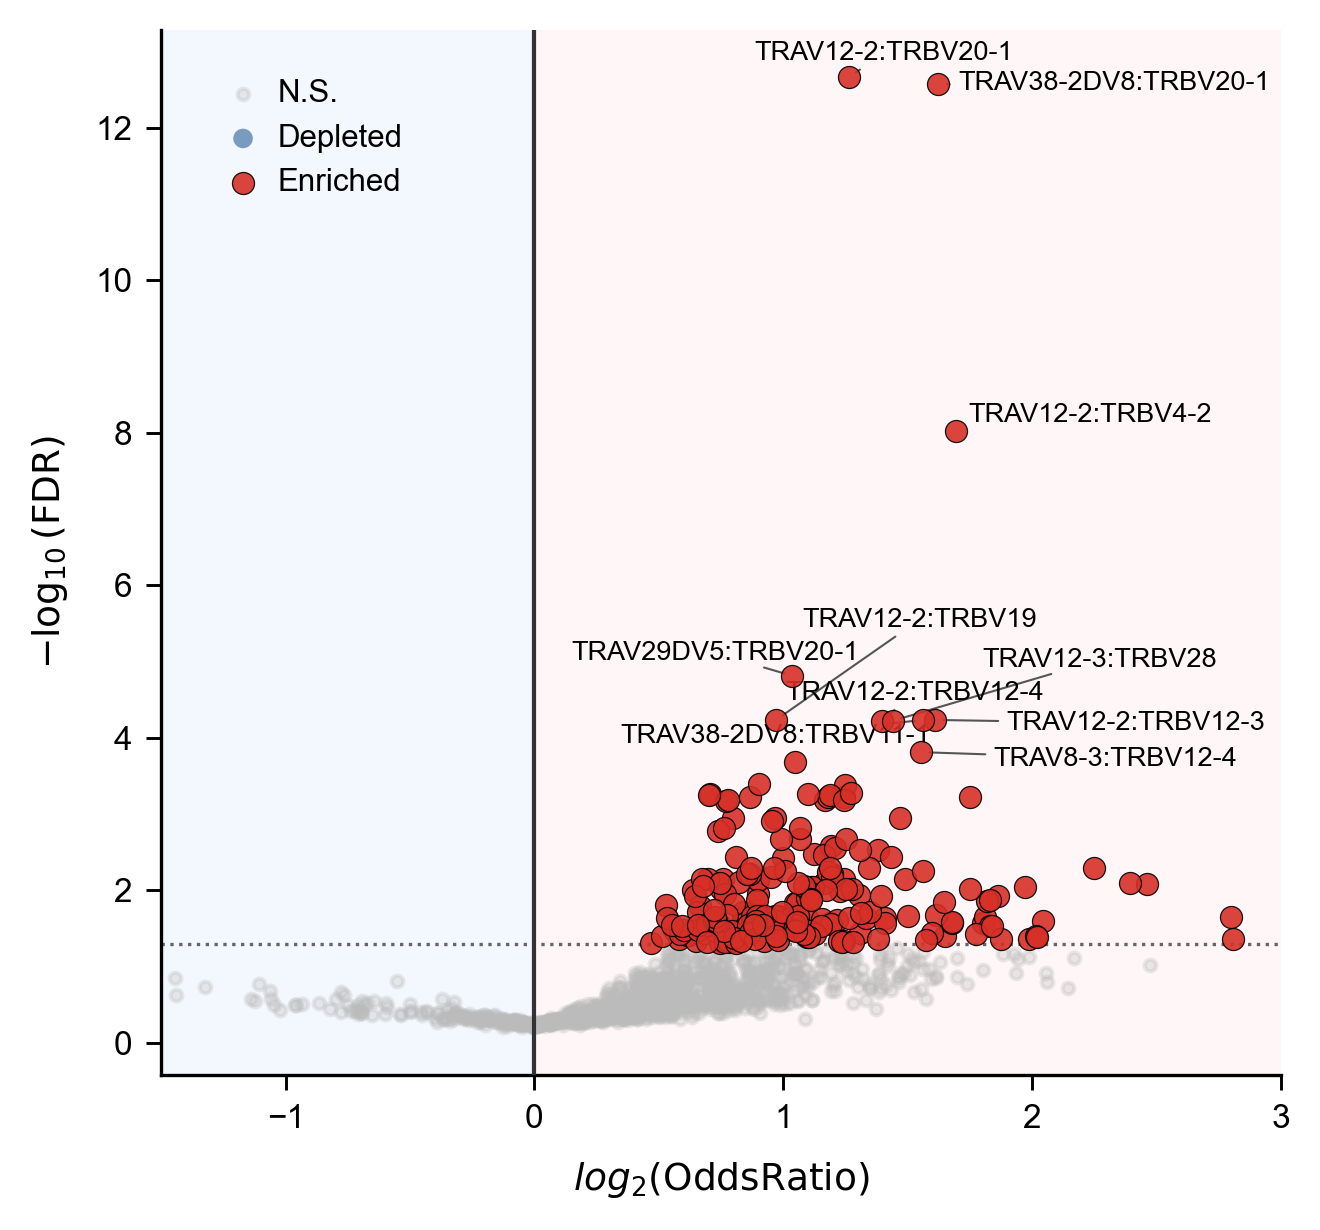

2026-05-04 16:04:30,162 - [INFO] - Rendering Lollipop Plot...
2026-05-04 16:04:30,243 - [INFO] - maxp pruned
2026-05-04 16:04:30,244 - [INFO] - LTSH dropped
2026-05-04 16:04:30,244 - [INFO] - cmap pruned
2026-05-04 16:04:30,244 - [INFO] - kern dropped
2026-05-04 16:04:30,247 - [INFO] - post pruned
2026-05-04 16:04:30,247 - [INFO] - PCLT dropped
2026-05-04 16:04:30,247 - [INFO] - JSTF dropped
2026-05-04 16:04:30,247 - [INFO] - DSIG dropped
2026-05-04 16:04:30,249 - [INFO] - GPOS pruned
2026-05-04 16:04:30,250 - [INFO] - GSUB pruned
2026-05-04 16:04:30,253 - [INFO] - glyf pruned
2026-05-04 16:04:30,254 - [INFO] - Added gid0 to subset
2026-05-04 16:04:30,254 - [INFO] - Added first four glyphs to subset
2026-05-04 16:04:30,255 - [INFO] - Closing glyph list over 'GSUB': 23 glyphs before
2026-05-04 16:04:30,255 - [INFO] - Glyph names: ['.notdef', '.null', 'E', 'O', 'P', 'R', 'T', 'a', 'c', 'd', 'e', 'five', 'h', 'i', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'space', 't']
2026-05-0

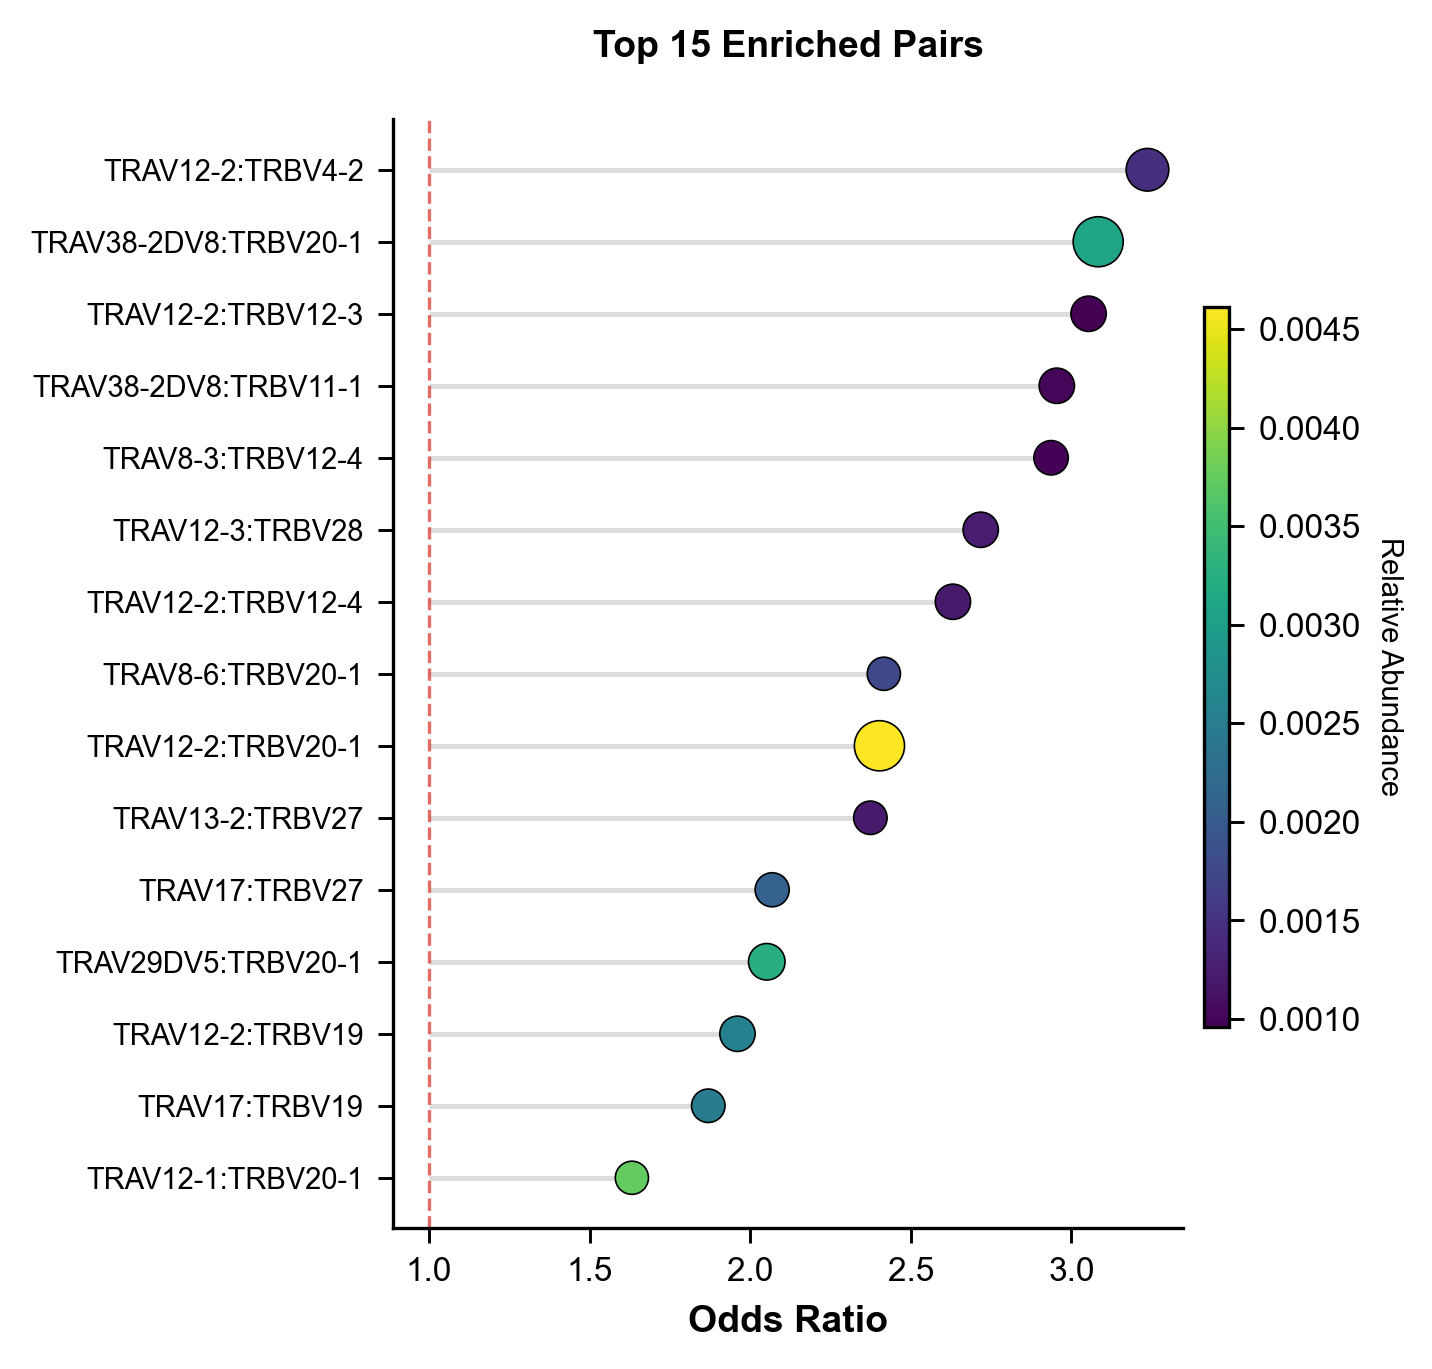

2026-05-04 16:04:30,510 - [INFO] - Pipeline completed successfully.


In [6]:
"""
TCR Repertoire HLA-A*02 Enrichment Analysis Pipeline
----------------------------------------------------
- Volcano Plot with shaded backgrounds for biological interpretation.
- Lollipop Plot for top candidates.
- Publication quality fonts (Arial) and vectorized PDF output.
"""

import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# =============================================================================
# 1. CONFIGURATION & STYLE SETUP
# =============================================================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s] - %(message)s')
logger = logging.getLogger(__name__)

# Nature-style aesthetics
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'figure.dpi': 300
})

# Paths & Parameters
TCR_PATH = 'tcr_data_with_hla.csv'
MIN_TOTAL_COUNT = 50   
TOP_SIG_PAIRS = 15     
FDR_THRESHOLD = 0.05
X_MIN, X_MAX = -1.5, 3

# =============================================================================
# 2. DATA PROCESSING MODULE
# =============================================================================

def load_and_prep_stats(path):
    """Loads data, filters artifacts, and calculates enrichment statistics."""
    logger.info("Loading dataset and applying QC...")
    df = pd.read_csv(path)
    
    # Artifact Removal
    df = df[~df['individual'].astype(str).str.contains('Multiplex', case=False, na=False)]
    df = df[df['cell_subtype_v3'].isin(['CD8+ Tn', 'CD4+ Tn'])].copy()
    
    # Define A*02 status
    a1_a02 = df['A_1'].astype(str).str.contains(r'A\*02', case=False, na=False, regex=True)
    a2_a02 = df['A_2'].astype(str).str.contains(r'A\*02', case=False, na=False, regex=True)
    df['is_a02pos'] = a1_a02 | a2_a02
    df['Major'] = np.where(df['cell_subtype_v3'].str.startswith('CD8'), 'CD8', 'CD4')
    df['AVBV'] = df['TRAV'].astype(str) + ':' + df['TRBV'].astype(str)
    
    # Aggregate counts for 2x2 table
    pos_df = df[df['is_a02pos']].copy()
    neg_df = df[~df['is_a02pos']].copy()
    pc = pos_df.groupby(['AVBV', 'Major']).size().unstack(fill_value=0)
    nc = neg_df.groupby(['AVBV', 'Major']).size().unstack(fill_value=0)
    
    stats_df = pd.DataFrame(index=sorted(set(pc.index) | set(nc.index)))
    stats_df['a02pos_CD8'], stats_df['a02pos_CD4'] = pc.get('CD8', 0), pc.get('CD4', 0)
    stats_df['a02neg_CD8'], stats_df['a02neg_CD4'] = nc.get('CD8', 0), nc.get('CD4', 0)
    stats_df = stats_df.fillna(0).astype(int)
    stats_df['grand_total'] = stats_df.sum(axis=1)
    
    stats_df = stats_df[stats_df['grand_total'] >= MIN_TOTAL_COUNT].copy()

    logger.info(f"Running Fisher's Exact Tests on {len(stats_df)} gene pairs...")
    def run_fisher(row):
        table = [[row['a02pos_CD8'], row['a02pos_CD4']], [row['a02neg_CD8'], row['a02neg_CD4']]]
        odds, pval = fisher_exact(table)
        if odds > 1: _, pval = fisher_exact(table, alternative='greater')
        else: _, pval = fisher_exact(table, alternative='less')
        return pd.Series([odds, pval])

    stats_df[['odds_ratio', 'p_val']] = stats_df.apply(run_fisher, axis=1)
    
    valid = stats_df['p_val'].notna()
    stats_df.loc[valid, 'fdr'] = multipletests(stats_df.loc[valid, 'p_val'], method='fdr_bh')[1]
    stats_df['log_or'] = np.log2(stats_df['odds_ratio'].clip(lower=1e-3))
    stats_df['neg_log10_fdr'] = -np.log10(stats_df['fdr'].clip(lower=1e-20))
    
    return stats_df

# =============================================================================
# 3. VISUALIZATION MODULE
# =============================================================================

def plot_volcano(df, output_name):
    """Renders volcano plot with shaded backgrounds and integer ticks."""
    logger.info("Rendering Shaded Volcano Plot...")
    fig, ax = plt.subplots(figsize=(4.5, 4.2), dpi=300)
    
    # 1. Add Shaded Background Colors (Before plotting points)
    # Depleted side (Left) - Light Blue-ish
    ax.axvspan(X_MIN, 0, color='#F0F7FF', zorder=0, alpha=0.8)
    # Enriched side (Right) - Light Red-ish/Peach
    ax.axvspan(0, X_MAX, color='#FFF5F5', zorder=0, alpha=0.8)

    # 2. Scatter layers
    sig_enriched = (df['fdr'] < FDR_THRESHOLD) & (df['log_or'] > 0)
    sig_depleted = (df['fdr'] < FDR_THRESHOLD) & (df['log_or'] < 0)
    non_sig = df['fdr'] >= FDR_THRESHOLD
    
    ax.scatter(df[non_sig]['log_or'], df[non_sig]['neg_log10_fdr'], 
               c='#BBBBBB', s=8, alpha=0.3, label='N.S.', zorder=2)
    ax.scatter(df[sig_depleted]['log_or'], df[sig_depleted]['neg_log10_fdr'], 
               c='#5B84B1', s=22, alpha=0.8, edgecolors='none', label='Depleted', zorder=3)
    ax.scatter(df[sig_enriched]['log_or'], df[sig_enriched]['neg_log10_fdr'], 
               c='#D73027', s=28, alpha=0.9, edgecolors='black', linewidth=0.3, label='Enriched', zorder=4)
    
    # 3. Guidelines
    ax.axhline(-np.log10(FDR_THRESHOLD), color='#666666', ls=':', lw=0.8, zorder=1)
    ax.axvline(0, color='#333333', lw=1.0, zorder=5) # Central axis
    
    # 4. Axis Constraints
    ax.set_xlim(X_MIN, X_MAX)
    # MODIFICATION: Keep only integer ticks -1, 0, 1, 2, 3
    ax.set_xticks([-1, 0, 1, 2, 3])
    
    # 5. Labeling
    try:
        from adjustText import adjust_text
        visible_sig = df[sig_enriched & (df['log_or'] <= X_MAX)]
        top_to_label = visible_sig.nlargest(10, 'neg_log10_fdr')
        texts = [ax.text(row['log_or'], row['neg_log10_fdr'], idx, fontsize=6.5, fontweight='medium') 
                 for idx, row in top_to_label.iterrows()]
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='#555555', lw=0.5))
    except ImportError:
        logger.warning("adjustText not installed; labels may overlap.")

    ax.set_xlabel('$log_2(\mathrm{Odds Ratio})$', fontweight='bold', labelpad=6)
    ax.set_ylabel('$-\log_{10}(\mathrm{FDR})$', fontweight='bold', labelpad=6)
    
    # Clean spines
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.02, 0.98), handletextpad=0.1)
    
    plt.tight_layout()
    plt.savefig(output_name)
    plt.show()

def plot_lollipop(df, output_name):
    """Renders a significance-sorted lollipop plot."""
    logger.info("Rendering Lollipop Plot...")
    l_df = df[(df['fdr'] < FDR_THRESHOLD) & (df['odds_ratio'] > 1)].copy()
    if l_df.empty: return
        
    l_df = l_df.sort_values('fdr', ascending=True).head(TOP_SIG_PAIRS)
    l_df = l_df.sort_values('odds_ratio', ascending=True)
    
    l_df['prop'] = l_df['grand_total'] / df['grand_total'].sum()
    norm = Normalize(vmin=l_df['prop'].min(), vmax=l_df['prop'].max())
    colors = plt.cm.viridis(norm(l_df['prop']))
    sizes = 35 + (l_df['neg_log10_fdr'] / l_df['neg_log10_fdr'].max()) * 110

    fig, ax = plt.subplots(figsize=(3.4, 4.8), dpi=300)
    y_range = np.arange(len(l_df))
    ax.hlines(y_range, xmin=1, xmax=l_df['odds_ratio'], color='#DDDDDD', lw=1.2, zorder=1)
    ax.scatter(l_df['odds_ratio'], y_range, s=sizes, c=colors, edgecolor='black', linewidth=0.4, zorder=2)
    
    ax.axvline(x=1, color='#D73027', ls='--', lw=0.8, alpha=0.7)
    ax.set_yticks(y_range)
    ax.set_yticklabels(l_df.index, fontsize=7)
    ax.set_xlabel('Odds Ratio', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    
    # Add vertical colorbar
    cax = fig.add_axes([0.92, 0.25, 0.025, 0.5])
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=plt.cm.viridis), cax=cax)
    cbar.set_label('Relative Abundance', fontsize=7, rotation=270, labelpad=10)
    
    ax.set_title(f'Top {TOP_SIG_PAIRS} Enriched Pairs', pad=15, fontsize=9, fontweight='bold')
    plt.savefig(output_name, bbox_inches='tight')
    plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    try:
        # Corrected function call: load_and_prep_stats
        results = load_and_prep_stats(TCR_PATH)
        
        plot_volcano(results, 'fig5c_A02_Volcano_Shaded.pdf')
        plot_lollipop(results, 'fig5c_A02_Lollipop_Abundance.pdf')
        logger.info("Pipeline completed successfully.")
    except Exception as e:
        logger.error(f"Execution failed: {e}", exc_info=True)

2026-05-04 16:04:44,005 - [INFO] - Loading dataset for Global CD8 vs CD4 analysis...
2026-05-04 16:04:50,006 - [INFO] - Running Fisher's Exact Tests on 1590 gene pairs...
2026-05-04 16:04:52,273 - [INFO] - maxp pruned
2026-05-04 16:04:52,273 - [INFO] - LTSH dropped
2026-05-04 16:04:52,274 - [INFO] - cmap pruned
2026-05-04 16:04:52,274 - [INFO] - kern dropped
2026-05-04 16:04:52,277 - [INFO] - post pruned
2026-05-04 16:04:52,277 - [INFO] - PCLT dropped
2026-05-04 16:04:52,277 - [INFO] - JSTF dropped
2026-05-04 16:04:52,277 - [INFO] - DSIG dropped
2026-05-04 16:04:52,279 - [INFO] - GPOS pruned
2026-05-04 16:04:52,280 - [INFO] - GSUB pruned
2026-05-04 16:04:52,283 - [INFO] - glyf pruned
2026-05-04 16:04:52,284 - [INFO] - Added gid0 to subset
2026-05-04 16:04:52,284 - [INFO] - Added first four glyphs to subset
2026-05-04 16:04:52,284 - [INFO] - Closing glyph list over 'GSUB': 37 glyphs before
2026-05-04 16:04:52,285 - [INFO] - Glyph names: ['.notdef', '.null', 'A', 'B', 'D', 'E', 'N', 'R',

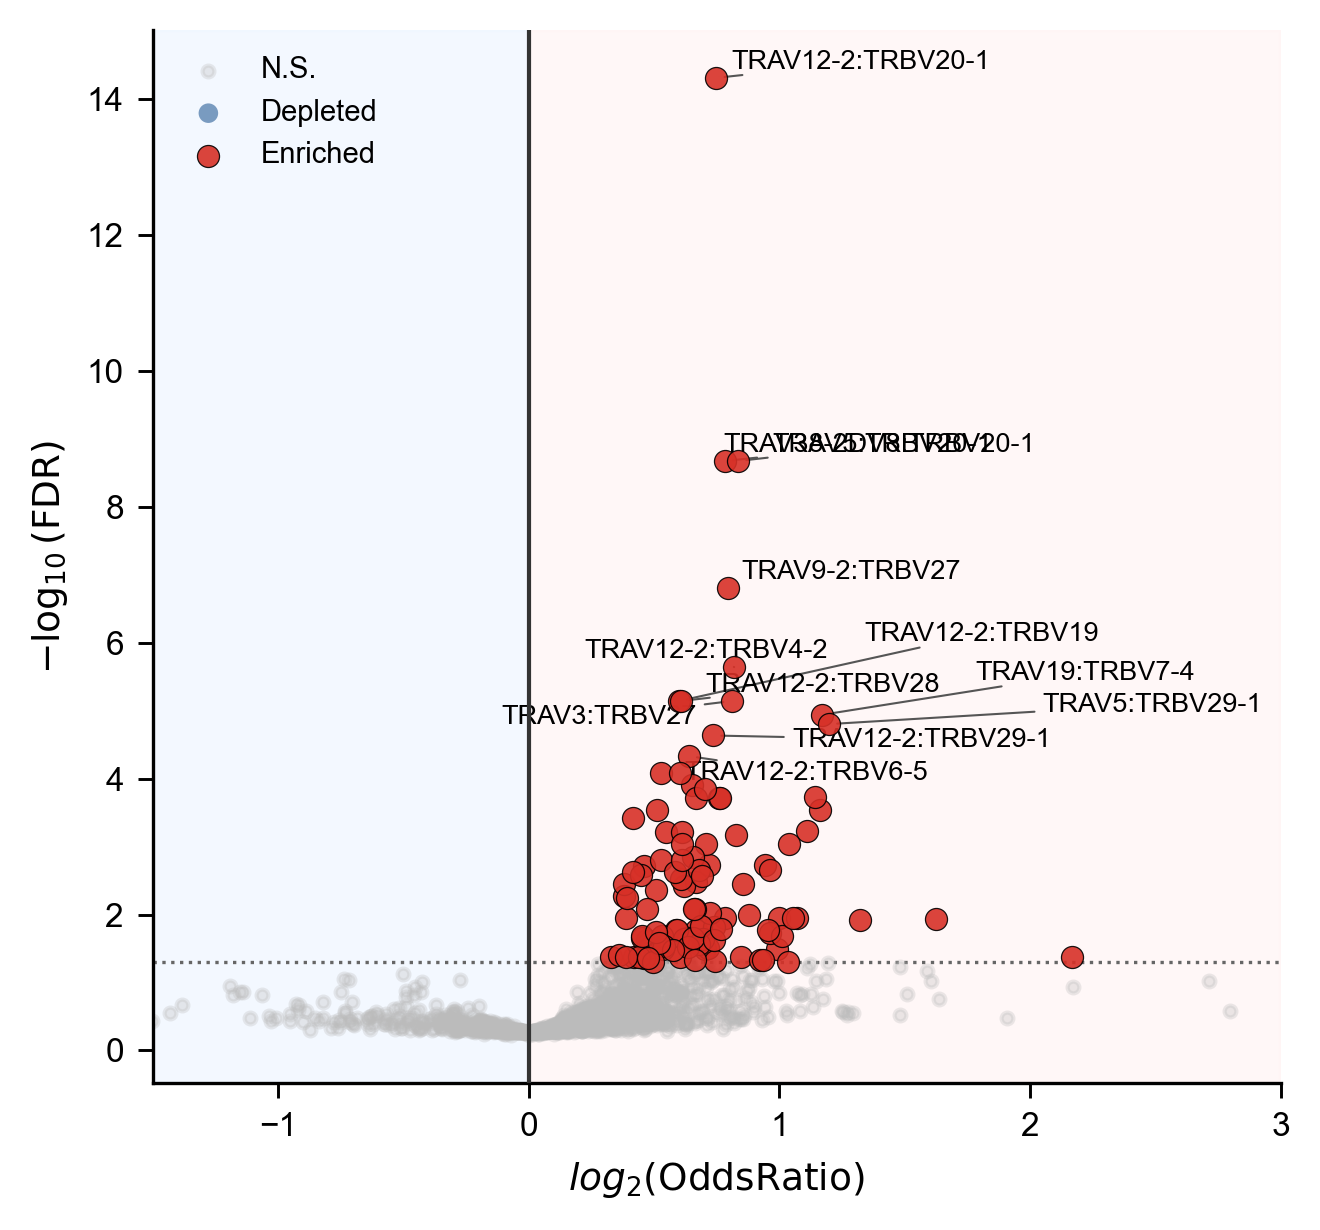

2026-05-04 16:04:52,741 - [INFO] - maxp pruned
2026-05-04 16:04:52,741 - [INFO] - LTSH dropped
2026-05-04 16:04:52,742 - [INFO] - cmap pruned
2026-05-04 16:04:52,742 - [INFO] - kern dropped
2026-05-04 16:04:52,745 - [INFO] - post pruned
2026-05-04 16:04:52,745 - [INFO] - PCLT dropped
2026-05-04 16:04:52,745 - [INFO] - JSTF dropped
2026-05-04 16:04:52,745 - [INFO] - DSIG dropped
2026-05-04 16:04:52,749 - [INFO] - GPOS pruned
2026-05-04 16:04:52,750 - [INFO] - GSUB pruned
2026-05-04 16:04:52,752 - [INFO] - glyf pruned
2026-05-04 16:04:52,753 - [INFO] - Added gid0 to subset
2026-05-04 16:04:52,754 - [INFO] - Added first four glyphs to subset
2026-05-04 16:04:52,754 - [INFO] - Closing glyph list over 'GSUB': 35 glyphs before
2026-05-04 16:04:52,755 - [INFO] - Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'E', 'G', 'O', 'P', 'R', 'T', 'a', 'b', 'c', 'd', 'e', 'eight', 'four', 'g', 'h', 'i', 'k', 'l', 'n', 'nonmarkingreturn', 'o', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'u

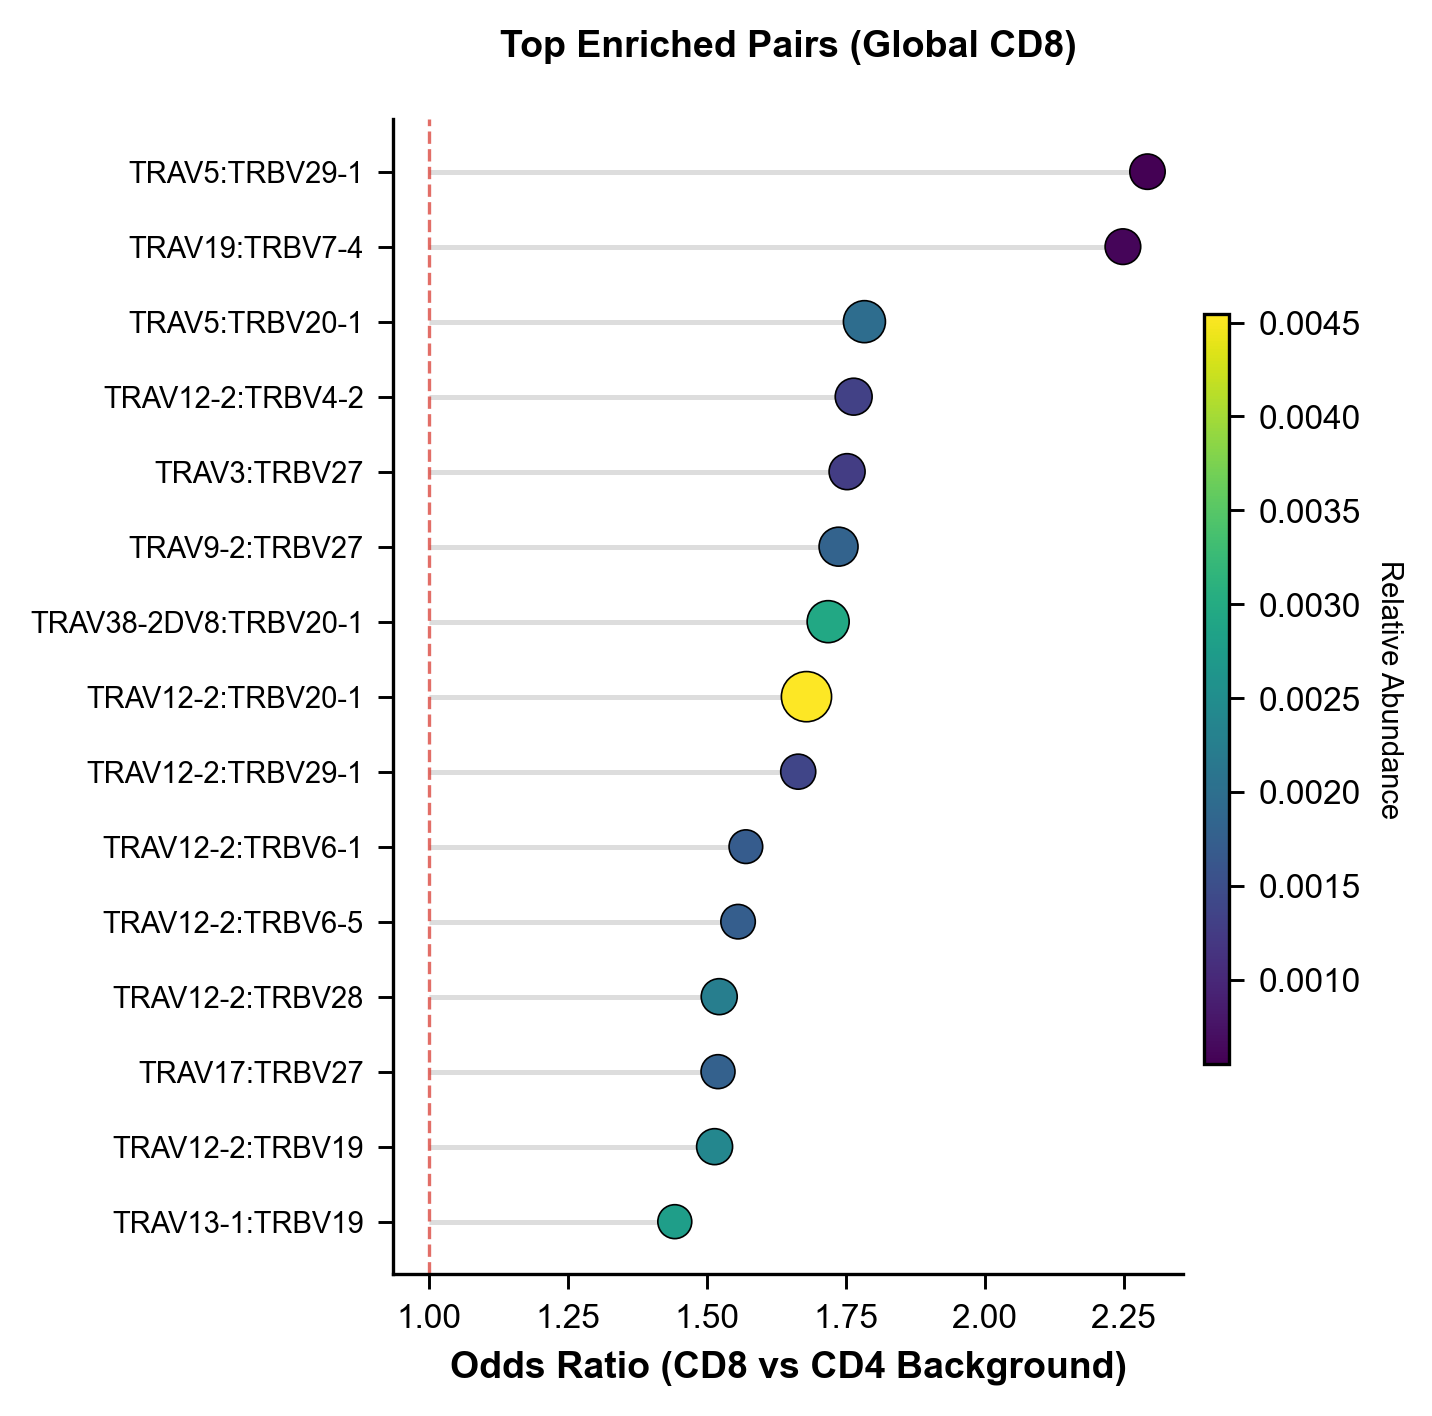

2026-05-04 16:04:53,071 - [INFO] - Global CD8 analysis completed successfully.


In [7]:
"""
TCR Repertoire HLA-A*02 Enrichment Analysis (Global CD8 vs CD4)
--------------------------------------------------------------
- Scope: All CD8+ T cells vs All CD4+ T cells (Internal Control).
- Visualization: Shaded Volcano Plot & Abundance-scaled Lollipop.
- Quality: Nature-style aesthetics, vectorized PDF output.
"""

import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# =============================================================================
# 1. CONFIGURATION & STYLE SETUP
# =============================================================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s] - %(message)s')
logger = logging.getLogger(__name__)

# Nature-style aesthetics
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.8,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'figure.dpi': 300
})

# Paths & Parameters
TCR_PATH = 'tcr_data_with_hla.csv'
MIN_TOTAL_COUNT = 50   # 过滤低频配对
TOP_SIG_PAIRS = 15     # Lollipop展示数量
FDR_THRESHOLD = 0.05
X_MIN, X_MAX = -1.5, 3

# =============================================================================
# 2. DATA PROCESSING MODULE
# =============================================================================

def load_and_prep_stats_global(path):
    """Loads data and computes enrichment for ALL CD8 vs ALL CD4."""
    logger.info("Loading dataset for Global CD8 vs CD4 analysis...")
    df = pd.read_csv(path)
    
    # 1. Artifact Removal (Remove Multiplex pools)
    df = df[~df['individual'].astype(str).str.contains('Multiplex', case=False, na=False)]
    
    # 2. Filter for all CD8 and CD4 lineages
    # Using 'cell_subtype_v3_major' to include all memory/naive/effector subsets
    lineage_col = 'cell_subtype_v3_major'
    df = df[df[lineage_col].isin(['CD8', 'CD4'])].copy()
    
    # 3. Define HLA-A*02 status (Robust Regex)
    a1_a02 = df['A_1'].astype(str).str.contains(r'A\*02', case=False, na=False, regex=True)
    a2_a02 = df['A_2'].astype(str).str.contains(r'A\*02', case=False, na=False, regex=True)
    df['is_a02pos'] = a1_a02 | a2_a02
    
    # 4. Map Lineage and Pairs
    df['Major'] = df[lineage_col]
    df['AVBV'] = df['TRAV'].astype(str) + ':' + df['TRBV'].astype(str)
    
    # 5. Aggregate counts for 2x2 table
    pos_df = df[df['is_a02pos']].copy()
    neg_df = df[~df['is_a02pos']].copy()
    
    pc = pos_df.groupby(['AVBV', 'Major']).size().unstack(fill_value=0)
    nc = neg_df.groupby(['AVBV', 'Major']).size().unstack(fill_value=0)
    
    stats_df = pd.DataFrame(index=sorted(set(pc.index) | set(nc.index)))
    stats_df['a02pos_CD8'], stats_df['a02pos_CD4'] = pc.get('CD8', 0), pc.get('CD4', 0)
    stats_df['a02neg_CD8'], stats_df['a02neg_CD4'] = nc.get('CD8', 0), nc.get('CD4', 0)
    
    stats_df = stats_df.fillna(0).astype(int)
    stats_df['grand_total'] = stats_df.sum(axis=1)
    
    # Filter by minimum frequency
    stats_df = stats_df[stats_df['grand_total'] >= MIN_TOTAL_COUNT].copy()

    logger.info(f"Running Fisher's Exact Tests on {len(stats_df)} gene pairs...")
    def run_fisher(row):
        # Table: [[A02pos_CD8, A02pos_CD4], [A02neg_CD8, A02neg_CD4]]
        table = [[row['a02pos_CD8'], row['a02pos_CD4']], [row['a02neg_CD8'], row['a02neg_CD4']]]
        odds, pval = fisher_exact(table)
        if odds > 1: _, pval = fisher_exact(table, alternative='greater')
        else: _, pval = fisher_exact(table, alternative='less')
        return pd.Series([odds, pval])

    stats_df[['odds_ratio', 'p_val']] = stats_df.apply(run_fisher, axis=1)
    
    # FDR and transformations
    valid = stats_df['p_val'].notna()
    stats_df.loc[valid, 'fdr'] = multipletests(stats_df.loc[valid, 'p_val'], method='fdr_bh')[1]
    stats_df['log_or'] = np.log2(stats_df['odds_ratio'].clip(lower=1e-3))
    stats_df['neg_log10_fdr'] = -np.log10(stats_df['fdr'].clip(lower=1e-20))
    
    return stats_df

# =============================================================================
# 3. VISUALIZATION MODULE
# =============================================================================

def plot_volcano_shaded(df, output_name):
    """Renders volcano plot with biological significance shading."""
    fig, ax = plt.subplots(figsize=(4.5, 4.2), dpi=300)
    
    # Shaded Backgrounds
    ax.axvspan(X_MIN, 0, color='#F0F7FF', zorder=0, alpha=0.8) # Depleted
    ax.axvspan(0, X_MAX, color='#FFF5F5', zorder=0, alpha=0.8) # Enriched

    # Points
    sig_enriched = (df['fdr'] < FDR_THRESHOLD) & (df['log_or'] > 0)
    sig_depleted = (df['fdr'] < FDR_THRESHOLD) & (df['log_or'] < 0)
    non_sig = df['fdr'] >= FDR_THRESHOLD
    
    ax.scatter(df[non_sig]['log_or'], df[non_sig]['neg_log10_fdr'], 
               c='#BBBBBB', s=8, alpha=0.3, label='N.S.', zorder=2)
    ax.scatter(df[sig_depleted]['log_or'], df[sig_depleted]['neg_log10_fdr'], 
               c='#5B84B1', s=22, alpha=0.8, edgecolors='none', label='Depleted', zorder=3)
    ax.scatter(df[sig_enriched]['log_or'], df[sig_enriched]['neg_log10_fdr'], 
               c='#D73027', s=28, alpha=0.9, edgecolors='black', linewidth=0.3, label='Enriched', zorder=4)
    
    ax.axhline(-np.log10(FDR_THRESHOLD), color='#666666', ls=':', lw=0.8, zorder=1)
    ax.axvline(0, color='#333333', lw=1.0, zorder=5)
    
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_xticks([-1, 0, 1, 2, 3])
    
    # Labeling top hits
    try:
        from adjustText import adjust_text
        visible_sig = df[sig_enriched & (df['log_or'] <= X_MAX)]
        top_to_label = visible_sig.nlargest(12, 'neg_log10_fdr')
        texts = [ax.text(row['log_or'], row['neg_log10_fdr'], idx, fontsize=6.5) 
                 for idx, row in top_to_label.iterrows()]
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='#555555', lw=0.5))
    except ImportError:
        pass

    ax.set_xlabel('$log_2(\mathrm{Odds Ratio})$', fontweight='bold')
    ax.set_ylabel('$-\log_{10}(\mathrm{FDR})$', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left', fontsize=7)
    
    plt.tight_layout()
    plt.savefig(output_name)
    plt.show()

def plot_lollipop_global(df, output_name):
    """Renders significance-sorted lollipop plot for top enriched pairs."""
    l_df = df[(df['fdr'] < FDR_THRESHOLD) & (df['odds_ratio'] > 1)].copy()
    if l_df.empty: return
        
    l_df = l_df.sort_values('fdr', ascending=True).head(TOP_SIG_PAIRS)
    l_df = l_df.sort_values('odds_ratio', ascending=True)
    
    l_df['prop'] = l_df['grand_total'] / df['grand_total'].sum()
    norm = Normalize(vmin=l_df['prop'].min(), vmax=l_df['prop'].max())
    colors = plt.cm.viridis(norm(l_df['prop']))
    sizes = 35 + (l_df['neg_log10_fdr'] / l_df['neg_log10_fdr'].max()) * 110

    fig, ax = plt.subplots(figsize=(3.4, 5.0), dpi=300)
    y_range = np.arange(len(l_df))
    ax.hlines(y_range, xmin=1, xmax=l_df['odds_ratio'], color='#DDDDDD', lw=1.2, zorder=1)
    ax.scatter(l_df['odds_ratio'], y_range, s=sizes, c=colors, edgecolor='black', linewidth=0.4, zorder=2)
    
    ax.axvline(x=1, color='#D73027', ls='--', lw=0.8, alpha=0.7)
    ax.set_yticks(y_range)
    ax.set_yticklabels(l_df.index, fontsize=7)
    ax.set_xlabel('Odds Ratio (CD8 vs CD4 Background)', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    
    # Legend
    cax = fig.add_axes([0.92, 0.25, 0.025, 0.5])
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=plt.cm.viridis), cax=cax)
    cbar.set_label('Relative Abundance', fontsize=7, rotation=270, labelpad=10)
    
    ax.set_title(f'Top Enriched Pairs (Global CD8)', pad=15, fontsize=9, fontweight='bold')
    plt.savefig(output_name, bbox_inches='tight')
    plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    try:
        # Run global analysis
        results_global = load_and_prep_stats_global(TCR_PATH)
        
        # Plot Global Results
        plot_volcano_shaded(results_global, 'figs5b_A02_Volcano_Global_CD8.pdf')
        plot_lollipop_global(results_global, 'figs5b_A02_Lollipop_Global_CD8.pdf')
        
        logger.info("Global CD8 analysis completed successfully.")
    except Exception as e:
        logger.error(f"Global analysis failed: {e}", exc_info=True)